# Option Pricing


### 1. Call Options and Pricing

1.1 The Black-Scholes Model

1.2 Greeks

1.3 Plots of the prices of the call option

1.4 Plots of the Greeks

### 2. Volatility

2.1 Historical Volatility

2.2 Historical Volatility of TSLA

### 3. Dynamical Delta Hedging

3.1 Hedging ATM Options

3.2 Hedging OTM Options

3.3 Hedging ITM Options

### 4. Implied Volatility

4.1 Implied Volatility of TSLA

4.2 Historical Volatility vs Implied Volatility

### 5. Merton Jump Process Model

5.1 Calibrations of Merton's Parameters

5.2 Option pricing using Merton Model

5.3 Dynamic Delta Hedging Using Merton Model

### 6. Summary

## 1. Call Options and Pricing

A call option $C(K, T)$ of an underlying asset (stocks, ETFs) gives the buyer the right (not the obligation) to purchase 100 share of the underlying asset at the strike price $K$ at the maturity time $T$ in the future. The buyer will exercise the call option when the spot price $S_T$ at time $T$ only when $S_T > K$. So the payout of the call option at time $T$ is $(S_T - K)^{+} = \max\{ S_T - K, 0\}$.

### 1.1 The Black-Scholes Model

Black-Scholes Model is a No-Arbitrage Pricing Model for pricing call options. It is simple but fundamental model, and is very popular partially due to its simplicity. A standard assumption is the ratio of the stock prices $S_T/S_0$ is lognormal: $dS=\mu S dt + \sigma S dZ$, or equally, $d\ln S = (\mu - \sigma^2/2)dt + \sigma dz$ using Ito's formula. Then the values of call options can computed using the Risk-Neutral Valuation. More precisely, let $r$ be the risk-free interest rate. Then the price of the call option with strike $K$ and maturity $T$ is 
$$c(S_0, K, T, r, \sigma) = e^{-rT}\hat{E}[(S_T - K)^{+}] = S_0 \Phi(d_1) - e^{-rT}K \Phi(d_2),$$
where $d_1 = \frac{\ln(S_0 /K) + (r+ \sigma^2/2)T}{\sigma \sqrt{T}}$, $d_2 = \frac{\ln(S_0 /K) + (r- \sigma^2/2)T}{\sigma \sqrt{T}}$, and $\Phi$ is the cumulative distribution function of a standard normal random variable. Intuitively, $\Phi(d_2)$ is the probability that the call option is exercised at time $T$: $\Phi(d_2)=\hat{P}[S_T > K]$, and $\Phi(d_1)$ is the rate of change of the call price with respect to the underlying asset $S_0$ (one of the Greeks: Delta).

### 1.2 Greeks

**Delta**: $\Delta=\frac{\partial c}{\partial S_0} =\Phi(d_1)$.
    An important identity used to derive Delta: $S_0 \phi(d_1) = e^{-r T}K \phi(d_2)$, where $\phi(x)$ is the probability density function.

**Gamma**: $\Gamma = \frac{\partial^2 c}{\partial S_0^2} = \frac{\phi(d_1)}{S_0 \sigma \sqrt{dt}}$.

**Theta** (time decay): $\Theta = -\frac{\partial c}{\partial T} = -\frac{S_0\phi(d_1)\sigma}{2\sqrt{dt}} - r e^{-rT}K \Phi(d_2)$.

**Vega**: $\nu = \frac{\partial c}{\partial \sigma} = S_0 \phi(d_1)\sqrt{T}$.

**Rho**: $\rho =  \frac{\partial c}{\partial r} = KT e^{-rT} \Phi(d_2)$

In [1]:
import time
from datetime import timedelta


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import norm, poisson
from scipy.optimize import least_squares
import yfinance as yf

In [2]:
class CallOptionBS:
    def __init__(self, S0, K, T, r, s):
        self.S0 = np.asarray(S0)
        self.K = np.asarray(K)
        self.T = np.asarray(T)
        self.r = np.asarray(r)
        self.s = np.asarray(s)
 
    def d1(self):
        return (np.log(self.S0 / self.K) + (self.r + 0.5 * self.s**2) * self.T) / (self.s * np.sqrt(self.T))
 
    def d2(self):
        return self.d1() - self.s * np.sqrt(self.T)
 
    def price(self):
        return self.S0 * norm.cdf(self.d1()) - self.K * np.exp(-self.r * self.T) * norm.cdf(self.d2())
 
    def delta(self):
        return norm.cdf(self.d1())
 
    def gamma(self):
        return norm.pdf(self.d1()) / (self.S0 * self.s * np.sqrt(self.T))
    
    def theta(self):
        return (-self.S0 * norm.pdf(self.d1()) * self.s / (2 * np.sqrt(self.T))
                - self.r * self.K * np.exp(-self.r * self.T) * norm.cdf(self.d2()))
    
    def vega(self):
        return self.S0 * norm.pdf(self.d1()) * np.sqrt(self.T)

    def rho(self):
        return self.K * self.T * np.exp(-self.r * self.T) * norm.cdf(self.d2())

In [3]:
# Call Option price and Greeks 
S0, K, T, r, s = 100, 120, 0.6, 0.04, 0.3
option = CallOptionBS(S0, K, T, r, s)

print(f"\nBlack-Scholes Model Results:")
print(f"Call Price: ${option.price():.4f}")
print(f"Delta: {option.delta():.4f}")
print(f"Gamma: {option.gamma():.6f}")
print(f"Theta: {option.theta():.4f}")
print(f"Vega: {option.vega():.4f}")
print(f"Rho: {option.rho():.4f}")


Black-Scholes Model Results:
Call Price: $3.6949
Delta: 0.2860
Gamma: 0.014634
Theta: -7.5815
Vega: 26.3413
Rho: 14.9429


### 1.3 Plots of the prices of the call option

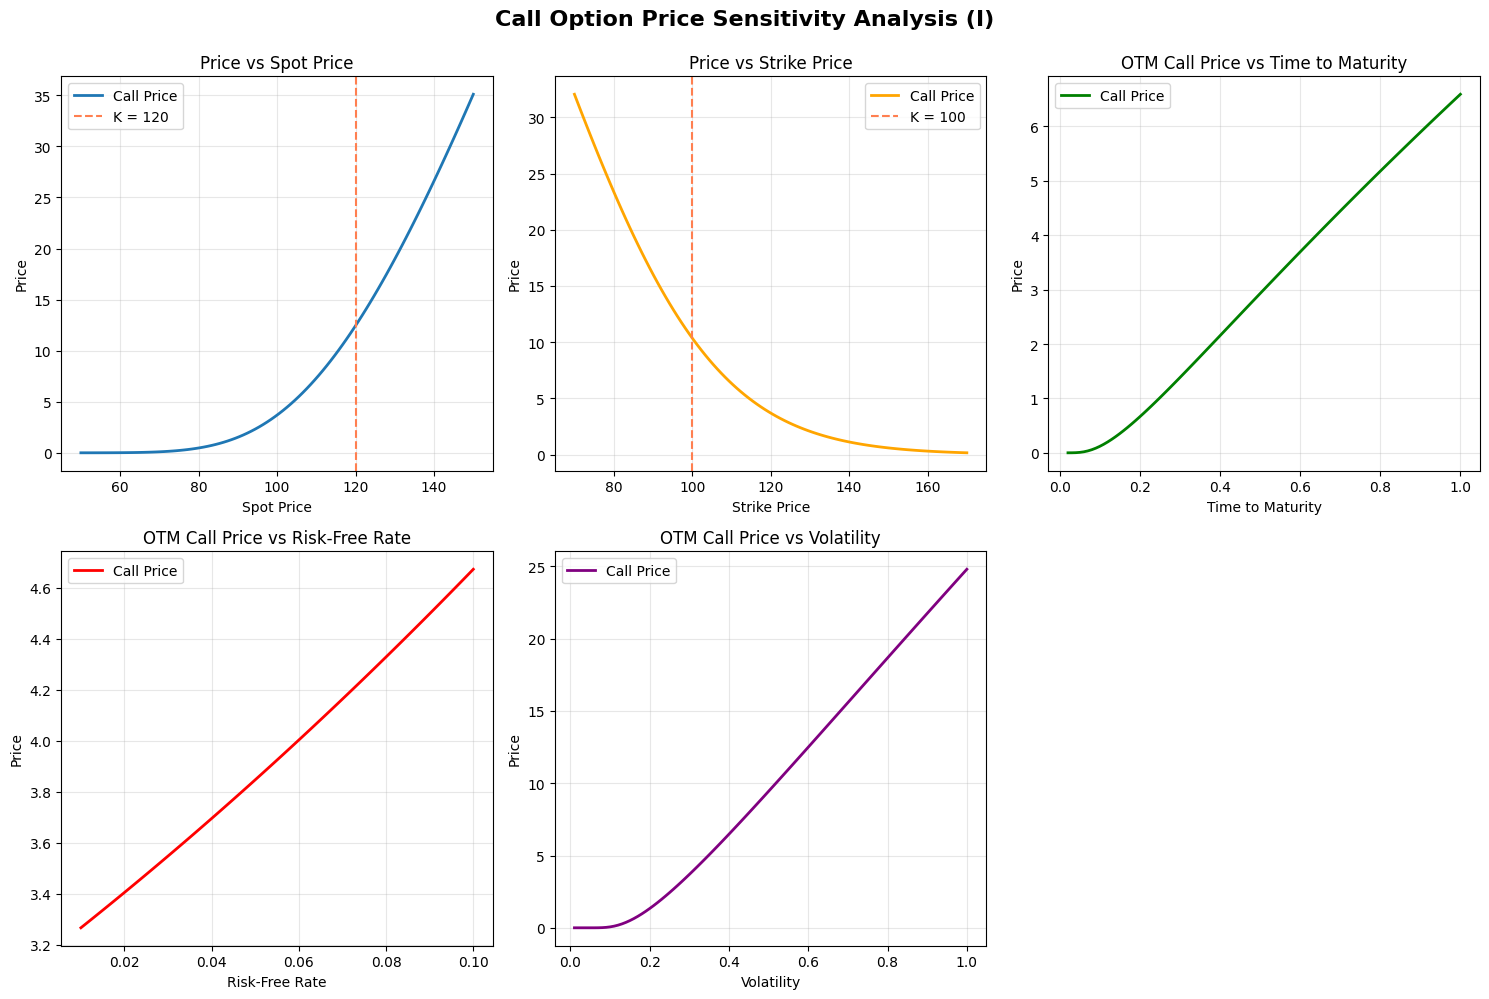

In [4]:
# OTM (Out-The-Money) Calls: K > S0
S0_base, K_base, T_base, r_base, s_base = 100, 120, 0.6, 0.04, 0.3

S0_range = np.linspace(50, 150, 100)
K_range = np.linspace(70, 170, 100)
T_range = np.linspace(0.02, 1, 100)
r_range = np.linspace(0.01, 0.10, 100)
sigma_range = np.linspace(0.01, 1, 100)

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle('Call Option Price Sensitivity Analysis (I)', fontsize=16, fontweight='bold', y=0.995)
 
# 1. Varying S0 (Spot Price)
ax = axes[0, 0]
prices_S0 = CallOptionBS(S0_range, K_base, T_base, r_base, s_base).price()
ax.plot(S0_range, prices_S0, linewidth=2, label='Call Price')
ax.axvline(x=K_base, color='coral', linestyle='--', linewidth=1.5, label=f'K = {K_base}')
ax.set_xlabel('Spot Price')
ax.set_ylabel('Price')
ax.set_title('Price vs Spot Price')
ax.legend()
ax.grid(True, alpha=0.3)
 
# 2. Varying K (Strike Price)
ax = axes[0, 1]
prices_K = CallOptionBS(S0_base, K_range, T_base, r_base, s_base).price() 
ax.plot(K_range, prices_K, linewidth=2, label='Call Price', color='orange')
ax.axvline(x=S0_base, color='coral', linestyle='--', linewidth=1.5, label=f'K = {S0_base}')
ax.set_xlabel('Strike Price')
ax.set_ylabel('Price')
ax.set_title('Price vs Strike Price')
ax.legend()
ax.grid(True, alpha=0.3)
 
# 3. Varying T (Time to Maturity)
ax = axes[0, 2]
prices_T = CallOptionBS(S0_base, K_base, T_range, r_base, s_base).price()
ax.plot(T_range, prices_T, linewidth=2, label='Call Price', color='green')
ax.set_xlabel('Time to Maturity')
ax.set_ylabel('Price')
ax.set_title('OTM Call Price vs Time to Maturity')
ax.legend()
ax.grid(True, alpha=0.3)
 
# 4. Varying r (Risk-Free Rate)
ax = axes[1, 0]
prices_r = CallOptionBS(S0_base, K_base, T_base, r_range, s_base).price()
ax.plot(r_range, prices_r, linewidth=2, label='Call Price', color='red')
ax.set_xlabel('Risk-Free Rate')
ax.set_ylabel('Price')
ax.set_title('OTM Call Price vs Risk-Free Rate')
ax.legend()
ax.grid(True, alpha=0.3)
 
# 5. Varying sigma (Volatility)
ax = axes[1, 1]
prices_sigma = CallOptionBS(S0_base, K_base, T_base, r_base, sigma_range).price()
ax.plot(sigma_range, prices_sigma, linewidth=2, label='Call Price', color='purple')
ax.set_xlabel('Volatility')
ax.set_ylabel('Price')
ax.set_title('OTM Call Price vs Volatility')
ax.legend()
ax.grid(True, alpha=0.3)
 
# Hide the extra subplot
axes[1, 2].axis('off')

plt.subplots_adjust(hspace=0.5) 
plt.tight_layout()
plt.show()

Observation from these plots: the call option price is monotone with respect to all five variables. 

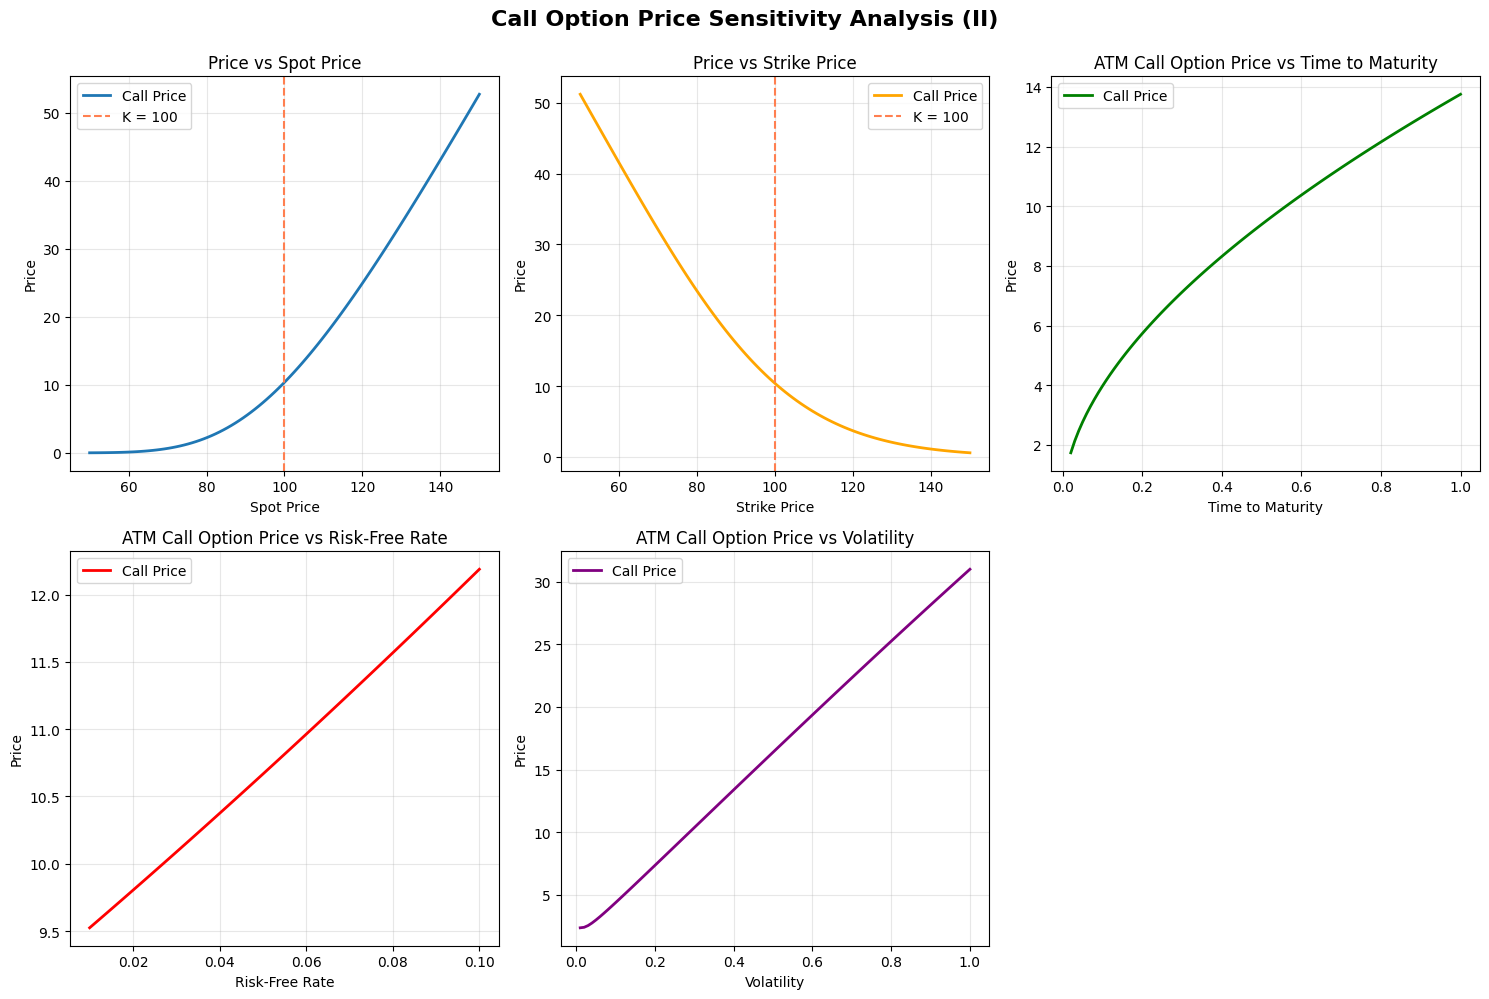

In [5]:
# ATM (At-The-Money) Calls: K = S0

S0_base, K_base, T_base, r_base, s_base = 100, 100, 0.6, 0.04, 0.3

S0_range = np.linspace(50, 150, 100)
K_range = np.linspace(50, 150, 100)
T_range = np.linspace(0.02, 1, 100)
r_range = np.linspace(0.01, 0.10, 100)
sigma_range = np.linspace(0.01, 1, 100)

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle('Call Option Price Sensitivity Analysis (II)', fontsize=16, fontweight='bold', y=0.995)
 
# 1. Varying S0 (Spot Price)
ax = axes[0, 0]
prices_S0 = CallOptionBS(S0_range, K_base, T_base, r_base, s_base).price()
ax.plot(S0_range, prices_S0, linewidth=2, label='Call Price')
ax.axvline(x=K_base, color='coral', linestyle='--', linewidth=1.5, label=f'K = {K_base}')
ax.set_xlabel('Spot Price')
ax.set_ylabel('Price')
ax.set_title('Price vs Spot Price')
ax.legend()
ax.grid(True, alpha=0.3)
 
# 2. Varying K (Strike Price)
ax = axes[0, 1]
prices_K = CallOptionBS(S0_base, K_range, T_base, r_base, s_base).price() 
ax.plot(K_range, prices_K, linewidth=2, label='Call Price', color='orange')
ax.axvline(x=S0_base, color='coral', linestyle='--', linewidth=1.5, label=f'K = {S0_base}')
ax.set_xlabel('Strike Price')
ax.set_ylabel('Price')
ax.set_title('Price vs Strike Price')
ax.legend()
ax.grid(True, alpha=0.3)
 
# 3. Varying T (Time to Maturity)
ax = axes[0, 2]
prices_T = CallOptionBS(S0_base, K_base, T_range, r_base, s_base).price()
ax.plot(T_range, prices_T, linewidth=2, label='Call Price', color='green')
ax.set_xlabel('Time to Maturity')
ax.set_ylabel('Price')
ax.set_title('ATM Call Option Price vs Time to Maturity')
ax.legend()
ax.grid(True, alpha=0.3)
 
# 4. Varying r (Risk-Free Rate)
ax = axes[1, 0]
prices_r = CallOptionBS(S0_base, K_base, T_base, r_range, s_base).price()
ax.plot(r_range, prices_r, linewidth=2, label='Call Price', color='red')
ax.set_xlabel('Risk-Free Rate')
ax.set_ylabel('Price')
ax.set_title('ATM Call Option Price vs Risk-Free Rate')
ax.legend()
ax.grid(True, alpha=0.3)
 
# 5. Varying sigma (Volatility)
ax = axes[1, 1]
prices_sigma = CallOptionBS(S0_base, K_base, T_base, r_base, sigma_range).price()
ax.plot(sigma_range, prices_sigma, linewidth=2, label='Call Price', color='purple')
ax.set_xlabel('Volatility')
ax.set_ylabel('Price')
ax.set_title('ATM Call Option Price vs Volatility')
ax.legend()
ax.grid(True, alpha=0.3)
 
# Hide the extra subplot
axes[1, 2].axis('off')

plt.subplots_adjust(hspace=0.5) 
plt.tight_layout()
plt.show()

OTM vs ATM: mostly similar plots, the biggest change happens on the time plot.

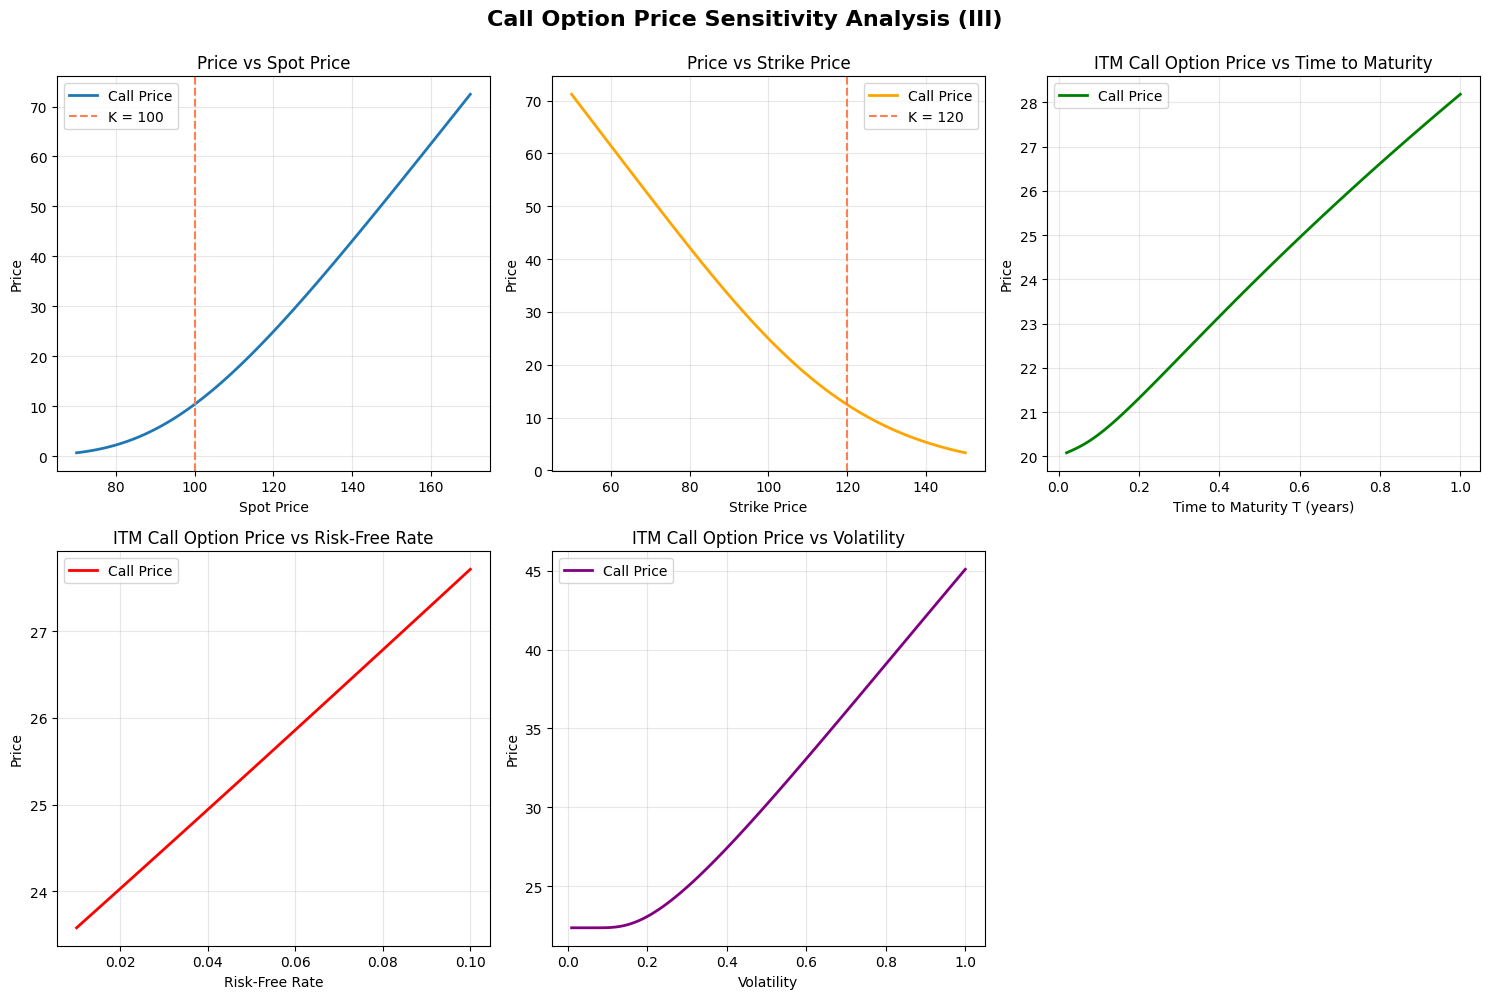

In [6]:
# ITM (In-The-Money) Calls: K < S0

S0_base, K_base, T_base, r_base, s_base = 120, 100, 0.6, 0.04, 0.3

S0_range = np.linspace(70, 170, 100)
K_range = np.linspace(50, 150, 100)
T_range = np.linspace(0.02, 1, 100)
r_range = np.linspace(0.01, 0.10, 100)
sigma_range = np.linspace(0.01, 1, 100)

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle('Call Option Price Sensitivity Analysis (III)', fontsize=16, fontweight='bold', y=0.995)
 
# 1. Varying S0 (Spot Price)
ax = axes[0, 0]
prices_S0 = CallOptionBS(S0_range, K_base, T_base, r_base, s_base).price()
ax.plot(S0_range, prices_S0, linewidth=2, label='Call Price')
ax.axvline(x=K_base, color='coral', linestyle='--', linewidth=1.5, label=f'K = {K_base}')
ax.set_xlabel('Spot Price')
ax.set_ylabel('Price')
ax.set_title('Price vs Spot Price')
ax.legend()
ax.grid(True, alpha=0.3)
 
# 2. Varying K (Strike Price)
ax = axes[0, 1]
prices_K = CallOptionBS(S0_base, K_range, T_base, r_base, s_base).price() 
ax.plot(K_range, prices_K, linewidth=2, label='Call Price', color='orange')
ax.axvline(x=S0_base, color='coral', linestyle='--', linewidth=1.5, label=f'K = {S0_base}')
ax.set_xlabel('Strike Price')
ax.set_ylabel('Price')
ax.set_title('Price vs Strike Price')
ax.legend()
ax.grid(True, alpha=0.3)
 
# 3. Varying T (Time to Maturity)
ax = axes[0, 2]
prices_T = CallOptionBS(S0_base, K_base, T_range, r_base, s_base).price()
ax.plot(T_range, prices_T, linewidth=2, label='Call Price', color='green')
ax.set_xlabel('Time to Maturity T (years)')
ax.set_ylabel('Price')
ax.set_title('ITM Call Option Price vs Time to Maturity')
ax.legend()
ax.grid(True, alpha=0.3)
 
# 4. Varying r (Risk-Free Rate)
ax = axes[1, 0]
prices_r = CallOptionBS(S0_base, K_base, T_base, r_range, s_base).price()
ax.plot(r_range, prices_r, linewidth=2, label='Call Price', color='red')
ax.set_xlabel('Risk-Free Rate')
ax.set_ylabel('Price')
ax.set_title('ITM Call Option Price vs Risk-Free Rate')
ax.legend()
ax.grid(True, alpha=0.3)
 
# 5. Varying sigma (Volatility)
ax = axes[1, 1]
prices_sigma = CallOptionBS(S0_base, K_base, T_base, r_base, sigma_range).price()
ax.plot(sigma_range, prices_sigma, linewidth=2, label='Call Price', color='purple')
ax.set_xlabel('Volatility')
ax.set_ylabel('Price')
ax.set_title('ITM Call Option Price vs Volatility')
ax.legend()
ax.grid(True, alpha=0.3)
 
# Hide the extra subplot
axes[1, 2].axis('off')

plt.subplots_adjust(hspace=0.5) 
plt.tight_layout()
plt.show()

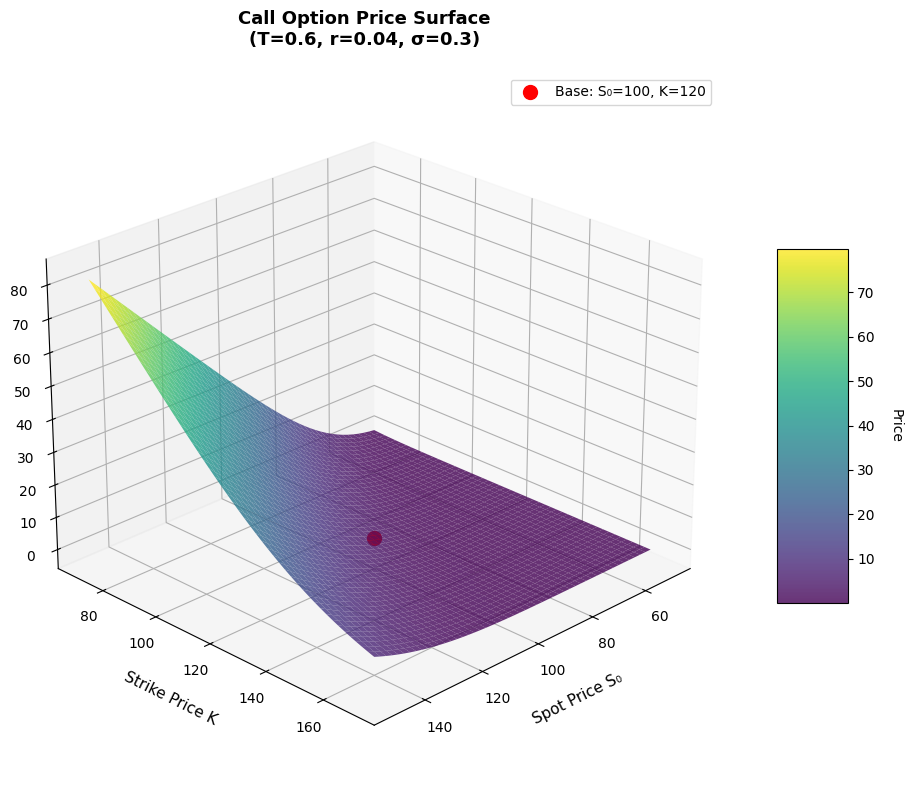

In [7]:
# Call Option Price Surface over (S0, K)
# Base parameters
S0_base, K_base, T_base, r_base, s_base = 100, 120, 0.6, 0.04, 0.3
 
# Create mesh grid for S0 and K
S0_range = np.linspace(50, 150, 50)
K_range = np.linspace(70, 170, 50)
S0_mesh, K_mesh = np.meshgrid(S0_range, K_range)
 
# Flatten the mesh for computation
S0_flat = S0_mesh.flatten()
K_flat = K_mesh.flatten()
 
# Compute prices on the mesh
call_option = CallOptionBS(S0_flat, K_flat, T_base, r_base, s_base)
prices_flat = call_option.price()
prices_mesh = prices_flat.reshape(S0_mesh.shape)
 
# Create 3D surface plot
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')
 
# Plot surface
surf = ax.plot_surface(S0_mesh, K_mesh, prices_mesh, cmap='viridis', alpha=0.8, edgecolor='none')
 
# Add labels and title
ax.set_xlabel('Spot Price S₀', fontsize=11, labelpad=10)
ax.set_ylabel('Strike Price K', fontsize=11, labelpad=10)
ax.set_zlabel('Call Price', fontsize=11, labelpad=10)
ax.set_title('Call Option Price Surface\n(T=0.6, r=0.04, σ=0.3)', fontsize=13, fontweight='bold', pad=20)
 
# Add colorbar
cbar = fig.colorbar(surf, ax=ax, shrink=0.5, aspect=5)
cbar.set_label('Price', rotation=270, labelpad=20)
 
# Mark base point
base_option = CallOptionBS(S0_base, K_base, T_base, r_base, s_base)
base_price = float(base_option.price())
ax.scatter([S0_base], [K_base], [base_price], color='red', s=100, marker='o', label=f'Base: S₀={S0_base}, K={K_base}')
ax.legend(fontsize=10)
 
# Adjust viewing angle
ax.view_init(elev=25, azim=45)

plt.tight_layout() 
plt.show()
 

### 1.4 Plots of the Greeks

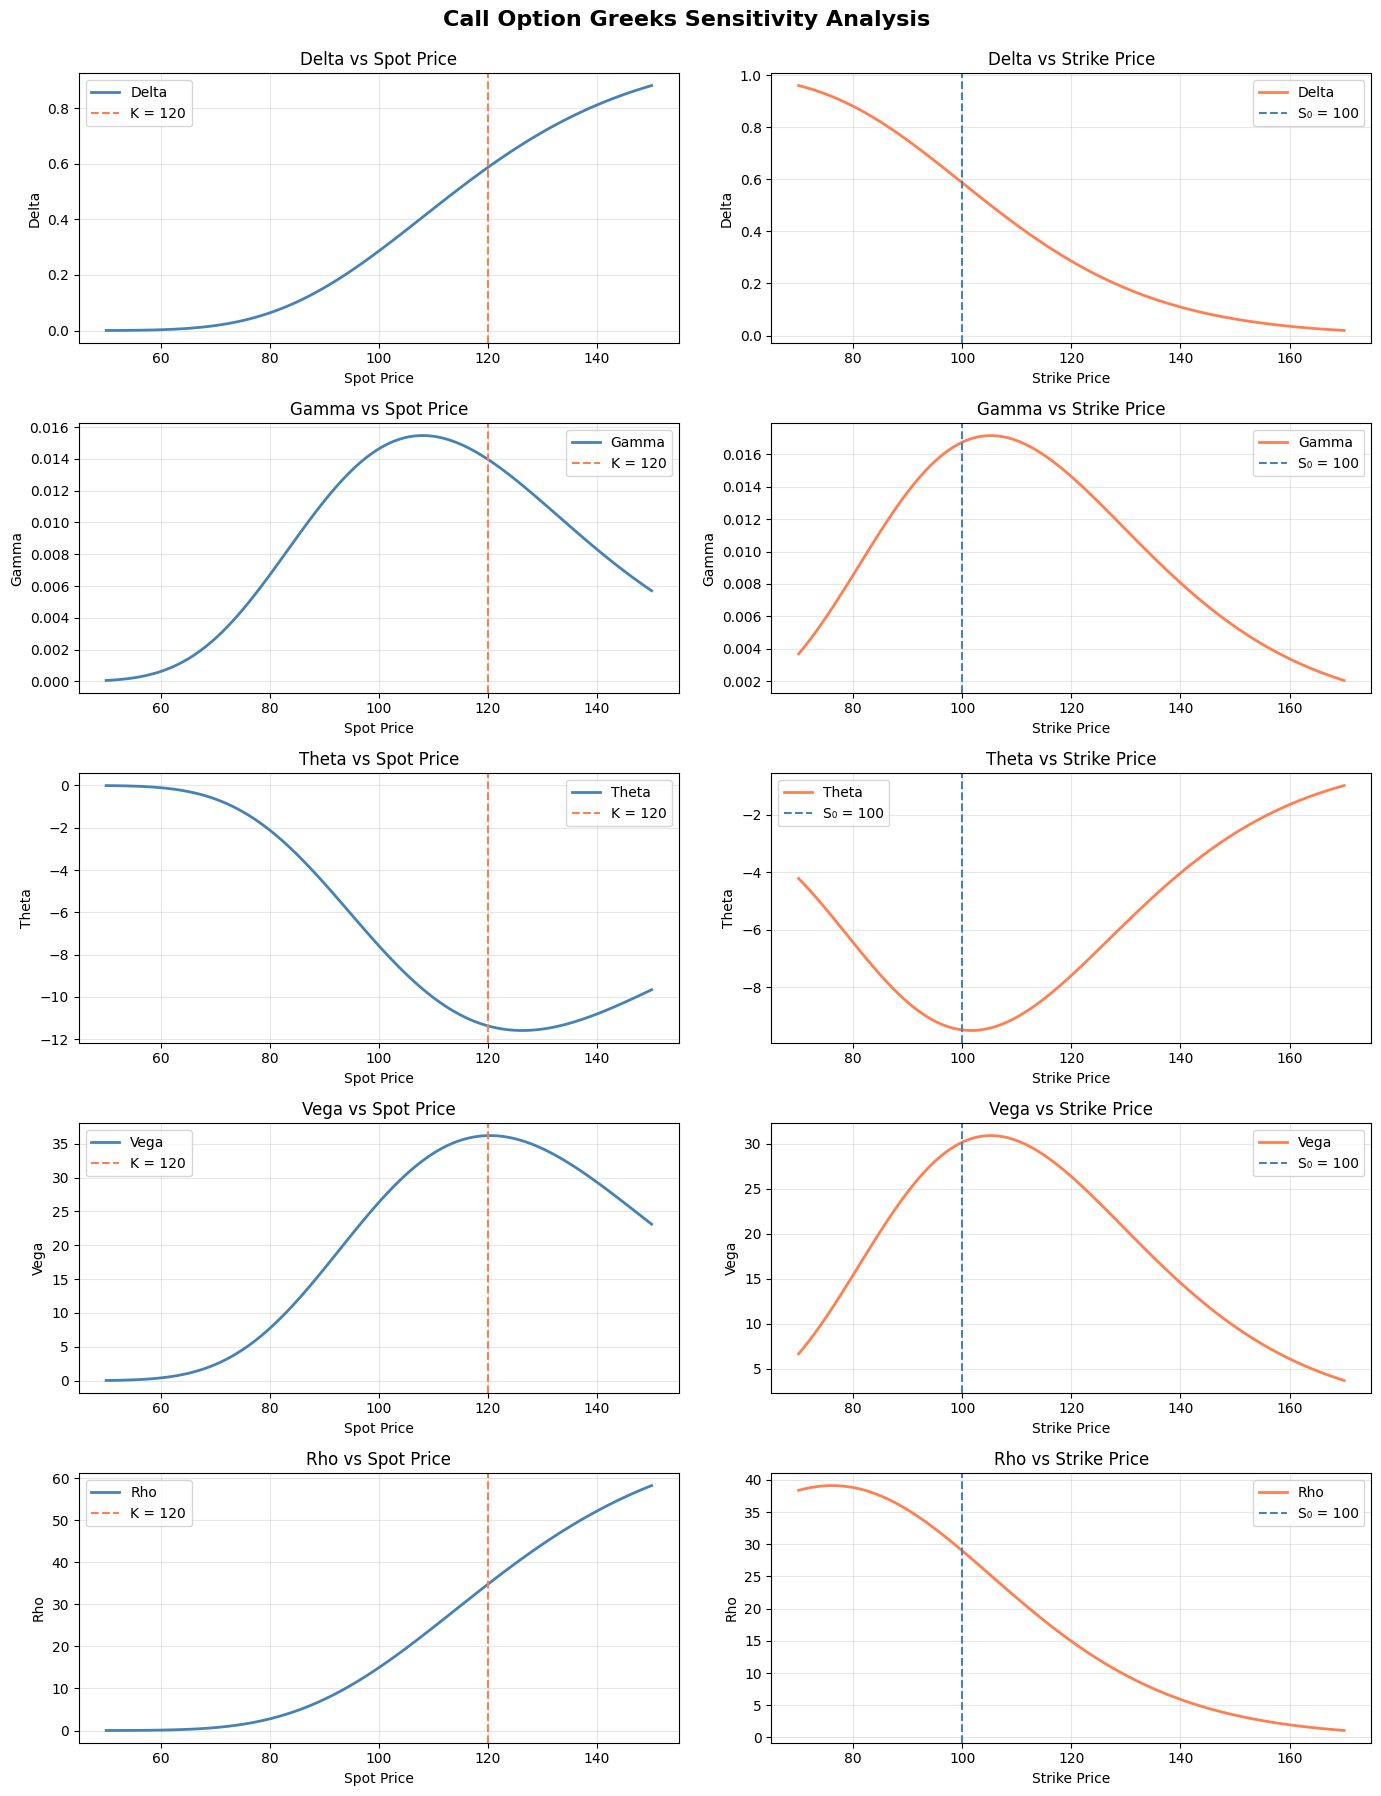

In [8]:
# Base parameters
S0_base, K_base, T_base, r_base, s_base = 100, 120, 0.6, 0.04, 0.3
 
# Range for varying parameters
S0_range = np.linspace(50, 150, 100)
K_range = np.linspace(70, 170, 100)
 
# Create figure with 5x2 subplots
fig, axes = plt.subplots(5, 2, figsize=(14, 18))
fig.suptitle('Call Option Greeks Sensitivity Analysis', fontsize=16, fontweight='bold', y=0.995)
 
# Row 0: Delta
# Delta vs S0
ax = axes[0, 0]
delta_S0 = CallOptionBS(S0_range, K_base, T_base, r_base, s_base).delta()
ax.plot(S0_range, delta_S0, linewidth=2, label='Delta', color='steelblue')
ax.axvline(x=K_base, color='coral', linestyle='--', linewidth=1.5, label=f'K = {K_base}')
ax.set_xlabel('Spot Price')
ax.set_ylabel('Delta')
ax.set_title('Delta vs Spot Price')
ax.legend()
ax.grid(True, alpha=0.3)
 
# Delta vs K
ax = axes[0, 1]
delta_K = CallOptionBS(S0_base, K_range, T_base, r_base, s_base).delta()
ax.plot(K_range, delta_K, linewidth=2, label='Delta', color='coral')
ax.axvline(x=S0_base, color='steelblue', linestyle='--', linewidth=1.5, label=f'S₀ = {S0_base}')
ax.set_xlabel('Strike Price')
ax.set_ylabel('Delta')
ax.set_title('Delta vs Strike Price')
ax.legend()
ax.grid(True, alpha=0.3)
 
# Row 1: Gamma
# Gamma vs S0
ax = axes[1, 0]
gamma_S0 = CallOptionBS(S0_range, K_base, T_base, r_base, s_base).gamma()
ax.plot(S0_range, gamma_S0, linewidth=2, label='Gamma', color='steelblue')
ax.axvline(x=K_base, color='coral', linestyle='--', linewidth=1.5, label=f'K = {K_base}')
ax.set_xlabel('Spot Price')
ax.set_ylabel('Gamma')
ax.set_title('Gamma vs Spot Price')
ax.legend()
ax.grid(True, alpha=0.3)
 
# Gamma vs K
ax = axes[1, 1]
gamma_K = CallOptionBS(S0_base, K_range, T_base, r_base, s_base).gamma()
ax.plot(K_range, gamma_K, linewidth=2, label='Gamma', color='coral')
ax.axvline(x=S0_base, color='steelblue', linestyle='--', linewidth=1.5, label=f'S₀ = {S0_base}')
ax.set_xlabel('Strike Price')
ax.set_ylabel('Gamma')
ax.set_title('Gamma vs Strike Price')
ax.legend()
ax.grid(True, alpha=0.3)
 
# Row 2: Theta
# Theta vs S0
ax = axes[2, 0]
theta_S0 = CallOptionBS(S0_range, K_base, T_base, r_base, s_base).theta()
ax.plot(S0_range, theta_S0, linewidth=2, label='Theta', color='steelblue')
ax.axvline(x=K_base, color='coral', linestyle='--', linewidth=1.5, label=f'K = {K_base}')
ax.set_xlabel('Spot Price')
ax.set_ylabel('Theta')
ax.set_title('Theta vs Spot Price')
ax.legend()
ax.grid(True, alpha=0.3)
 
# Theta vs K
ax = axes[2, 1]
theta_K = CallOptionBS(S0_base, K_range, T_base, r_base, s_base).theta()
ax.plot(K_range, theta_K, linewidth=2, label='Theta', color='coral')
ax.axvline(x=S0_base, color='steelblue', linestyle='--', linewidth=1.5, label=f'S₀ = {S0_base}')
ax.set_xlabel('Strike Price')
ax.set_ylabel('Theta')
ax.set_title('Theta vs Strike Price')
ax.legend()
ax.grid(True, alpha=0.3)
 
# Row 3: Vega
# Vega vs S0
ax = axes[3, 0]
vega_S0 = CallOptionBS(S0_range, K_base, T_base, r_base, s_base).vega()
ax.plot(S0_range, vega_S0, linewidth=2, label='Vega', color='steelblue')
ax.axvline(x=K_base, color='coral', linestyle='--', linewidth=1.5, label=f'K = {K_base}')
ax.set_xlabel('Spot Price')
ax.set_ylabel('Vega')
ax.set_title('Vega vs Spot Price')
ax.legend()
ax.grid(True, alpha=0.3)
 
# Vega vs K
ax = axes[3, 1]
vega_K = CallOptionBS(S0_base, K_range, T_base, r_base, s_base).vega()
ax.plot(K_range, vega_K, linewidth=2, label='Vega', color='coral')
ax.axvline(x=S0_base, color='steelblue', linestyle='--', linewidth=1.5, label=f'S₀ = {S0_base}')
ax.set_xlabel('Strike Price')
ax.set_ylabel('Vega')
ax.set_title('Vega vs Strike Price')
ax.legend()
ax.grid(True, alpha=0.3)
 
# Row 4: Rho
# Rho vs S0
ax = axes[4, 0]
rho_S0 = CallOptionBS(S0_range, K_base, T_base, r_base, s_base).rho()
ax.plot(S0_range, rho_S0, linewidth=2, label='Rho', color='steelblue')
ax.axvline(x=K_base, color='coral', linestyle='--', linewidth=1.5, label=f'K = {K_base}')
ax.set_xlabel('Spot Price')
ax.set_ylabel('Rho')
ax.set_title('Rho vs Spot Price')
ax.legend()
ax.grid(True, alpha=0.3)
 
# Rho vs K
ax = axes[4, 1]
rho_K = CallOptionBS(S0_base, K_range, T_base, r_base, s_base).rho()
ax.plot(K_range, rho_K, linewidth=2, label='Rho', color='coral')
ax.axvline(x=S0_base, color='steelblue', linestyle='--', linewidth=1.5, label=f'S₀ = {S0_base}')
ax.set_xlabel('Strike Price')
ax.set_ylabel('Rho')
ax.set_title('Rho vs Strike Price')
ax.legend()
ax.grid(True, alpha=0.3)

plt.subplots_adjust(hspace=0.5)
plt.tight_layout()
plt.show() 

Delta is monotone, but Gamma, Theta and Vega are not monotone. Rho appears to be non-monotone wrt K.

## 2. Volatility

The variable $\sigma$ in the definition of stock price model determines how volatile the price change $S_T/S_0$ can be. It is called the volatility of the stock, and tells us how uncertain we are about the price of the stock in the future. Among the five variables in our pricing function $c(S_0, K, T, r, \sigma)$, $S_0$ can be either observed, $K$ and $T$ can be chosen and $r$ can be computed. Only the variable $\sigma$ is unknown and cannot be determined. 

In Black-Scholes model, the volatility $\sigma$ is assumed to be constant. In real world, the volatility changes all the time. A naive estimate of the volatility can be computed using the historical data, since the daily change of prices is a realization of the volatility.

### 2.1 Historical Volatility

Suppose we want to value the call options with maturity $T$. Then we look back the daily prices of the underlying asset for the past $T$. For convenience, we will use forward time from $S_0$ to $S_T$. Let $u_i = \ln(S_i/S_{i-1})$, $1\le i \le n$. Let $s$ be the standard deviation of the $u_i$ s. Then the volatility $\sigma$ can be estimated as $\hat\sigma = s\cdot \sqrt{N}$, where $N=252$ is the number of trading days in a year.

In [9]:
tsla_current = yf.Ticker("TSLA")
tsla_history = tsla_current.history(start="2017-01-01", end="2023-01-01")

In [10]:
tsla_history.head()

,Open,High,Low,Close,Volume,Dividends,Stock Splits
Date,,,,,,,
2017-01-03 00:00:00-05:00,14.324000,14.688667,14.064000,14.466000,88849500,0.0,0.0
2017-01-04 00:00:00-05:00,14.316667,15.200000,14.287333,15.132667,168202500,0.0,0.0
2017-01-05 00:00:00-05:00,15.094667,15.165333,14.796667,15.116667,88675500,0.0,0.0
2017-01-06 00:00:00-05:00,15.128667,15.354000,15.030000,15.267333,82918500,0.0,0.0
2017-01-09 00:00:00-05:00,15.264667,15.461333,15.200000,15.418667,59692500,0.0,0.0


In [11]:
tsla_history.index = pd.to_datetime(tsla_history.index.date)

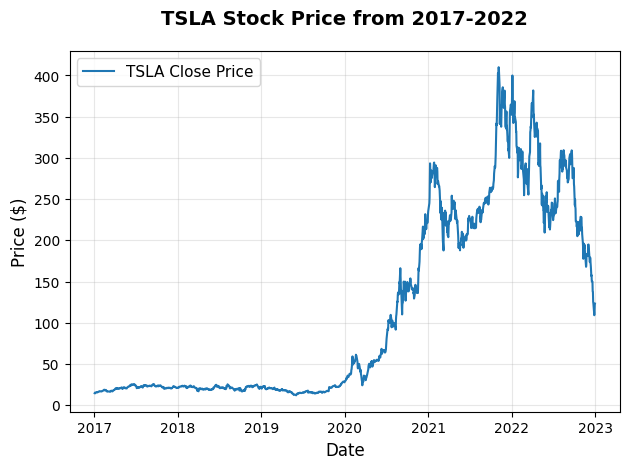

In [12]:
plt.plot(tsla_history["Close"], label="TSLA Close Price")
plt.title("TSLA Stock Price from 2017-2022", fontsize=14, fontweight='bold', y=1.05)
plt.xlabel("Date", fontsize=12)
plt.ylabel("Price ($)", fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [13]:
tsla_pct = tsla_history["Close"].pct_change()
tsla_log_returns = np.log(1 + tsla_pct).fillna(0)

tsla_log_returns

2017-01-03    0.000000
2017-01-04    0.045055
2017-01-05   -0.001058
2017-01-06    0.009918
2017-01-09    0.009863
                ...   
2022-12-23   -0.017707
2022-12-27   -0.121138
2022-12-28    0.032553
2022-12-29    0.077726
2022-12-30    0.011102
Name: Close, Length: 1510, dtype: float64

### 2.2 Historical Volatility of TSLA

Results using trading windows of 2 months (approx 40 trading days)

In [14]:
# options with maturity date in two-month: 40 trading days
window_size = 40
trading_days_in_a_year = 252

tsla_historical_volatility = tsla_log_returns.rolling(window=window_size).std() * np.sqrt(trading_days_in_a_year)


hv_filtered = tsla_historical_volatility['2018-01-02':'2022-12-30']

In [15]:
hv_filtered

2018-01-02    0.296163
2018-01-03    0.292677
2018-01-04    0.292084
2018-01-05    0.291324
2018-01-08    0.327258
                ...   
2022-12-23    0.633389
2022-12-27    0.681890
2022-12-28    0.693026
2022-12-29    0.731935
2022-12-30    0.726627
Name: Close, Length: 1259, dtype: float64

In [16]:
print(f"Mean HV: {hv_filtered.mean():.4f}")
print(f"Std of HV: {hv_filtered.std():.4f}")
print(f"Min HV: {hv_filtered.min():.4f}")
print(f"Max HV: {hv_filtered.max():.4f}")

Mean HV: 0.6108
Std of HV: 0.2110
Min HV: 0.2302
Max HV: 1.4392


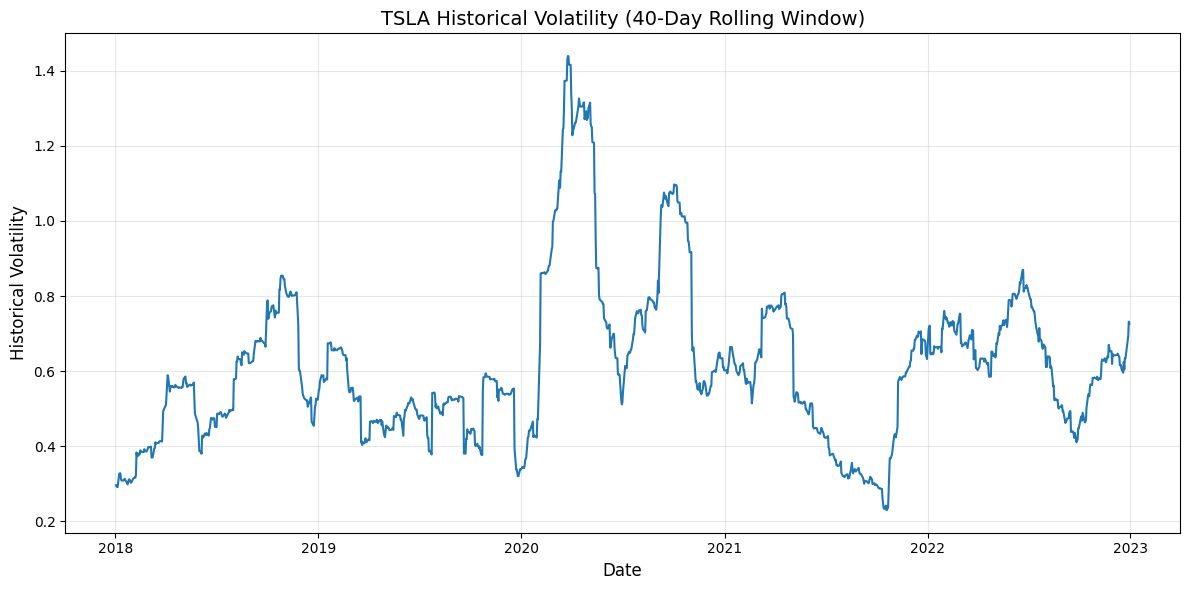

In [17]:
# Plot
plt.figure(figsize=(12, 6))
plt.plot(hv_filtered.index, hv_filtered.values)
plt.title('TSLA Historical Volatility (40-Day Rolling Window)', fontsize=14)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Historical Volatility', fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

For most of the time, $\sigma_{hv} \in [0.4, 0.8]$. There are months with increased volatility. 

In [18]:
close_filtered = tsla_history["Close"]['2018-01-02':'2022-12-30']

tsla_close_hv = pd.DataFrame({
    'Close_Price': close_filtered,
    'Historical_Volatility': hv_filtered
})

tsla_close_hv

,Close_Price,Historical_Volatility
2018-01-02,21.368668,0.296163
2018-01-03,21.150000,0.292677
2018-01-04,20.974667,0.292084
2018-01-05,21.105333,0.291324
2018-01-08,22.427334,0.327258
...,...,...
2022-12-23,123.150002,0.633389
2022-12-27,109.099998,0.681890
2022-12-28,112.709999,0.693026
2022-12-29,121.820000,0.731935


## 3. Dynamical Delta Hedging

Suppose a trader sells a call option $C(K, T)$ at $t_0=0$. Then at time $T$, if the stock price $S_T > K$, then the seller would suffer a lost of $S_T - K$. To hedge this potential loss, the sell can buy certain shares of the underlying stock. Recall that $c(S_0, K, T, r, \sigma)$ is the risk-neutral valuation of the call option $C(K, T)$. Suppose a portfolio consists of a short call and $x$ shares of the stock. Then the net payout of the portfolio at $t_0=0$ is $P=c(S_0, K, T, r, \sigma) - x\cdot S_0$. Delta hedging builds a portfolio that is not sensitive to small changes of the underlying price: 
$$\frac{\partial P}{\partial S_0} = \Delta(S_0, K, T, r, \sigma) - x =0.$$
That is, at time $t_0 =0$, the seller can hedge their short call position by holding $\Delta_0 = \Delta(S_0, K, T, r, \sigma)$ shares of the underlying stock. By the same argument, at time $t_i$, the seller can hedge their short call position by holding $\Delta_i = \Delta(S_i, K, T-t_i, r, \sigma)$ shares of the underlying stock. So the seller has to rebalance frequently by adjusting their hedging position from $\Delta_i$ to $\Delta_{i+1}$ at time $T_{i+1}$, that is, sell $\Delta_i$ and immediately buy $\Delta_{i+1}$, which result in net buying or selling shares depending on the sign of $\Delta_{i+1}- \Delta_{i}$. 

### The effectiveness of Dynamic Delta Hedging

As the stock price rises toward and beyond the strike $K$, $\Delta_i$ increases toward 1, meaning the seller holds increasingly more shares to offset the growing liability from the short call. Conversely, as the stock price falls well below $K$, $\Delta_i$ decreases toward 0, meaning the seller reduces the hedging position since the call option becomes less likely to be exercised.

The payout of the portfolio at $t_n =T$ (after selling the hedging shares), discounted to $t_0 =0$ is
$$P_T= e^{-rT}(S_T - K)^{+} - \sum_{i=0}^{n-1} (S_{i+1} - e^{r(t_{i+1} - t_{i})} S_i) \Delta_i\cdot e^{-r t_{i+1}}.$$
Taking (step-by-step conditional) risk-neutral expectation, we have
$$p_0(S_{[0,T]}, K, T, r, \sigma) = c(S_0, K, T, r, \sigma) - 0 = c(S_0, K, T, r, \sigma).$$
The hedged portfolio has the same risk-neutral valuation as the call option. But its payout is less sensitive to the price change of the underlying asset.

In [19]:
def dynamic_delta_hedging(S, hv, k, n, r=0.03, x=1):
    """
    Calculate dynamic delta hedging payout for a call option.
    
    Parameters:
    -----------
    S : array-like
        Array of closing prices (length >= n+1)
    hv : array-like
        Array of historical volatilities (length >= n+1)
    k : float
        Ratio of strike price over initial price: K = k * S[0]
    n : int
        Trading days to maturity (will be normalized by N=252)
    r : float
        Risk-free interest rate
    x : hedging ratio relative to Delta. 
        x > 1 means more hedging, x < 1 means less hedging
    
    Returns:
    --------
    payout : float
        Dynamic delta hedging payout
    """
    
    N = 252  # Annual trading days
    
    # Check if we have enough data points
    if len(S) < n + 1 or len(hv) < n + 1:
        return np.nan
    
    # Take the last n+1 data points
    S = np.asarray(S[-n-1:])
    hv = np.asarray(hv[-n-1:])
    
    # Strike price
    K = k * S[0]
    
    # Day n payout: discounted intrinsic value
    S_n = S[-1]
    payout = np.exp(-r * n / N) * max(S_n - K, 0)
    
    # Hedging cost: sum of (stock price change - hedging profit) * discount factor
    hedging_cost = 0.0
    
    for i in range(n):
        S_i = S[i]
        S_i_plus_1 = S[i + 1]
        hv_i = hv[i]
        
        # Time to maturity at step i
        T_i = (n - i) / N
        
        # Delta at step i
        delta_i = CallOptionBS(S_i, K, T_i, r, hv_i).delta()
        
        # Stock price change
        stock_change = S_i_plus_1 - np.exp(r / N) * S_i
        
        # Discount factor for step i+1
        discount = np.exp(-r * (i + 1) / N)
        
        # Hedging cost contribution
        hedging_cost += stock_change * x * delta_i * discount
    
    # Total payout
    total_payout = payout - hedging_cost
    
    return total_payout

### 3.1 Hedging ATM Options

In [20]:
# ATM Options with 2-month expiration 
# standard Delta Hedging: x = 1 
k = 1.0  # Ratio of Strike price over S0
n = 40    # Trading days
N = 252   # Annual trading days
r = 0.05  # Risk-free rate
T = n / N # Time to maturity in years
 
# Extract arrays
S_values = tsla_close_hv['Close_Price'].values
hv_values = tsla_close_hv['Historical_Volatility'].values
 
# Calculate metrics for each point
ddh_payouts = []
more_hedging_payouts = []
less_hedging_payouts = []
discounted_payouts = []
call_prices = []
dates = []
 
# Start from day n onwards
for i in range(n, len(tsla_close_hv)):
    S_0 = S_values[i - n]  # Initial price (n days ago)
    S_n = S_values[i]      # Final price (today)
    K = k * S_0
    hv_i = hv_values[i]
    
    # Dynamic delta hedging payout
    payout = dynamic_delta_hedging(S_values[:i+1], hv_values[:i+1], k, n, r, x=1)
    md_payout = dynamic_delta_hedging(S_values[:i+1], hv_values[:i+1], k, n, r, x=1.2)
    ld_payout = dynamic_delta_hedging(S_values[:i+1], hv_values[:i+1], k, n, r, x=0.8)
    ddh_payouts.append(payout)
    more_hedging_payouts.append(md_payout)
    less_hedging_payouts.append(ld_payout)
    
    # Actual option payout discounted to day 0: e^(-rT)max(S_n - K, 0)
    discounted_payout = np.exp(-r*T) * max(S_n - K, 0)
    discounted_payouts.append(discounted_payout)
    
    # Call option price at inception: c(S_0, K, T, r, hv)
    call_price = CallOptionBS(S_0, K, T, r, hv_i).price()
    call_prices.append(call_price)
    
    dates.append(tsla_close_hv.index[i].date())
 
# Create dataframe with all metrics
tsla_ddh_analysis = pd.DataFrame({
    'Close': S_values[n:len(S_values)],
    'Discounted_Payout': discounted_payouts,
    'Call_Price': call_prices,
    'DDH_Payout': ddh_payouts,
    'MD_Payout': more_hedging_payouts,
    'LD_Payout': less_hedging_payouts
}, index=dates)
 

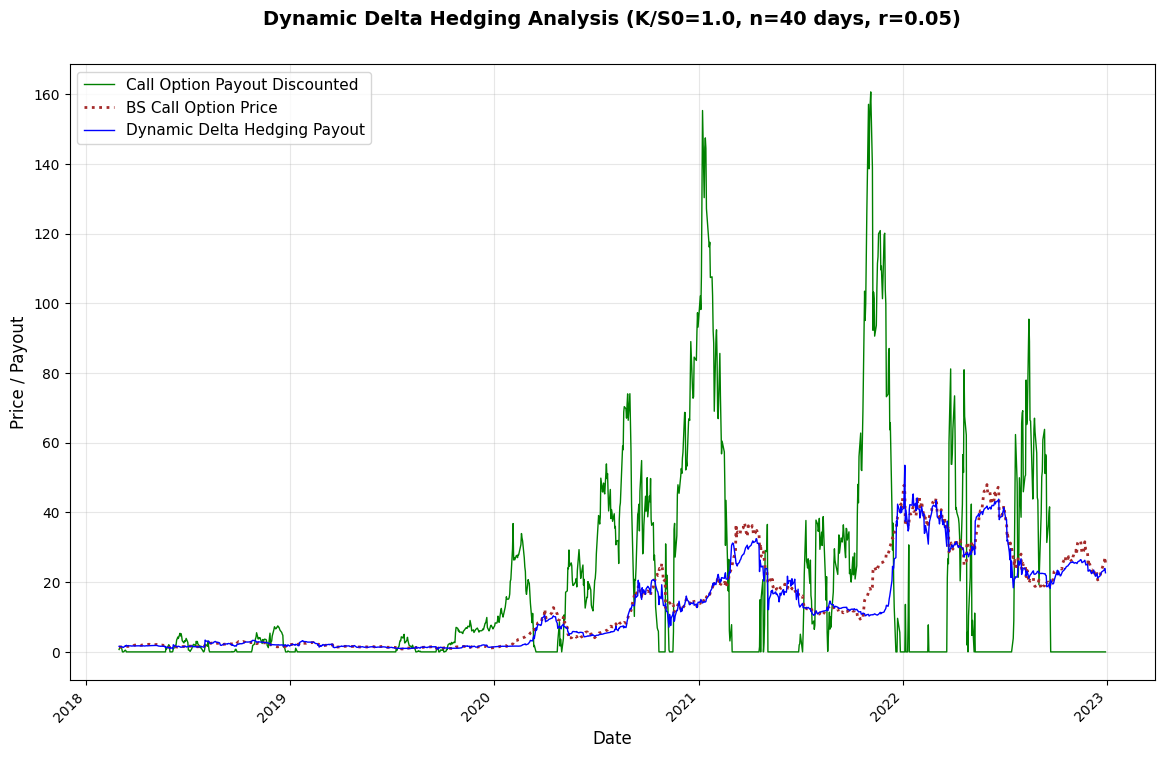

Dynamic Delta Hedging Analysis (K/S0=1.0, n=40 days, r=0.05)
Date range: 2018-03-01 to 2022-12-30

                Close  Discounted_Payout  Call_Price  DDH_Payout  MD_Payout  \
2018-03-01  22.062000           0.687852    1.429937    1.577906   1.755917   
2018-03-02  22.341333           1.181916    1.415383    1.547503   1.620621   
2018-03-05  22.223333           1.238796    1.402312    1.521059   1.577511   
2018-03-06  21.879999           0.768542    1.417928    1.522605   1.673418   
2018-03-07  22.153334           0.000000    1.402552    1.349952   1.619943   

            LD_Payout  
2018-03-01   1.399895  
2018-03-02   1.474386  
2018-03-05   1.464606  
2018-03-06   1.371792  
2018-03-07   1.079962  

Summary statistics:
             Close  Discounted_Payout   Call_Price   DDH_Payout    MD_Payout  \
count  1219.000000        1219.000000  1219.000000  1219.000000  1219.000000   
mean    135.371571          17.022282    13.278639    12.374904    11.445429   
std     118.051053   

In [21]:
# Plot
fig, ax = plt.subplots(figsize=(14, 8))
 
# Plot three curves 
ax.plot(tsla_ddh_analysis.index, tsla_ddh_analysis['Discounted_Payout'], 
        linewidth=1, label='Call Option Payout Discounted', color='green')

ax.plot(tsla_ddh_analysis.index, tsla_ddh_analysis['Call_Price'], 
        linewidth=2, label='BS Call Option Price', color='brown', linestyle=':')

ax.plot(tsla_ddh_analysis.index, tsla_ddh_analysis['DDH_Payout'], 
        linewidth=1, label='Dynamic Delta Hedging Payout', color='blue')

#ax.plot(tsla_ddh_analysis.index, tsla_ddh_analysis['MD_Payout'], 
#        linewidth=1, label='More Hedging', color='blue', linestyle=':')

#ax.plot(tsla_ddh_analysis.index, tsla_ddh_analysis['LD_Payout'], 
#        linewidth=1, label='Less Hedging', color='blue', linestyle='--')
 
# Labels and formatting
ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Price / Payout', fontsize=12)
ax.set_title(f'Dynamic Delta Hedging Analysis (K/S0={k}, n={n} days, r={r})', 
             fontsize=14, fontweight='bold', y=1.05)
ax.legend(fontsize=11, loc='best')
ax.grid(True, alpha=0.3)
 
plt.xticks(rotation=45, ha='right')
 
plt.show()
 
# Print summary
print(f"Dynamic Delta Hedging Analysis (K/S0={k}, n={n} days, r={r})")
print(f"Date range: {tsla_ddh_analysis.index[0]} to {tsla_ddh_analysis.index[-1]}")
print(f"\n{tsla_ddh_analysis.head()}")
print(f"\nSummary statistics:")
print(tsla_ddh_analysis.describe())
 

### 3.2 Hedging OTM Options

In [22]:
# OTM Options
# standard Delta Hedging: x = 1 
k = 1.2  # Ratio of Strike price over S0
n = 40    # Trading days
N = 252   # Annual trading days
r = 0.05  # Risk-free rate
T = n / N # Time to maturity in years
 
# Extract arrays
S_values = tsla_close_hv['Close_Price'].values
hv_values = tsla_close_hv['Historical_Volatility'].values
 
# Calculate metrics for each point
ddh_payouts = []
more_hedging_payouts = []
less_hedging_payouts = []
discounted_payouts = []
call_prices = []
dates = []
 
# Start from day n onwards
for i in range(n, len(tsla_close_hv)):
    S_0 = S_values[i - n]  # Initial price (n days ago)
    S_n = S_values[i]      # Final price (today)
    K = k * S_0
    hv_i = hv_values[i]
    
    # Dynamic delta hedging payout
    payout = dynamic_delta_hedging(S_values[:i+1], hv_values[:i+1], k, n, r, x=1)
    md_payout = dynamic_delta_hedging(S_values[:i+1], hv_values[:i+1], k, n, r, x=1.2)
    ld_payout = dynamic_delta_hedging(S_values[:i+1], hv_values[:i+1], k, n, r, x=0.8)
    ddh_payouts.append(payout)
    more_hedging_payouts.append(md_payout)
    less_hedging_payouts.append(ld_payout)
    
    # Actual option payout discounted to day 0: e^(-rT)max(S_n - K, 0)
    discounted_payout = np.exp(-r*T) * max(S_n - K, 0)
    discounted_payouts.append(discounted_payout)
    
    # Call option price at inception: c(S_0, K, T, r, hv)
    call_price = CallOptionBS(S_0, K, T, r, hv_i).price()
    call_prices.append(call_price)
    
    dates.append(tsla_close_hv.index[i].date())
 
# Create dataframe with all metrics
tsla_ddh_analysis = pd.DataFrame({
    'Close': S_values[n:len(S_values)],
    'Discounted_Payout': discounted_payouts,
    'Call_Price': call_prices,
    'DDH_Payout': ddh_payouts,
    'MD_Payout': more_hedging_payouts,
    'LD_Payout': less_hedging_payouts
}, index=dates)
 

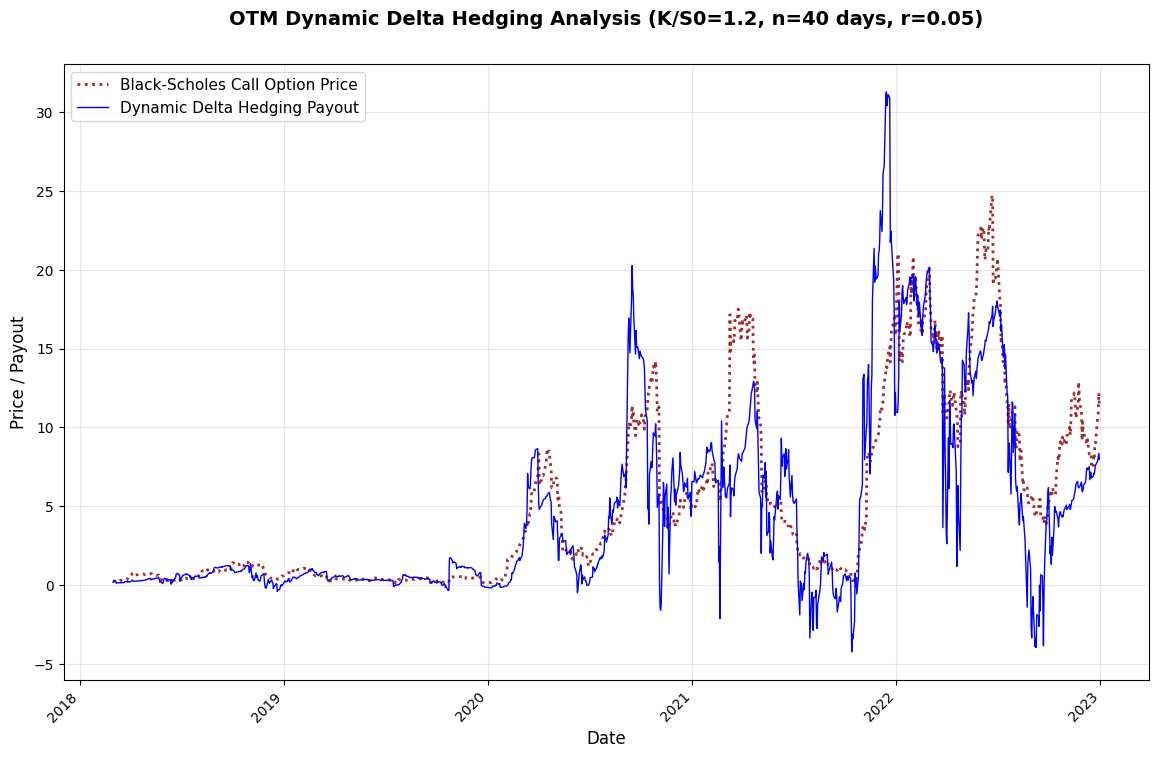

Dynamic Delta Hedging Analysis (K/S0=1.2, n=40 days, r=0.05)
Date range: 2018-03-01 to 2022-12-30

                Close  Discounted_Payout  Call_Price  DDH_Payout  MD_Payout  \
2018-03-01  22.062000                0.0    0.252564    0.183426   0.220111   
2018-03-02  22.341333                0.0    0.250027    0.216459   0.259751   
2018-03-05  22.223333                0.0    0.247154    0.254654   0.305585   
2018-03-06  21.879999                0.0    0.252819    0.253051   0.303661   
2018-03-07  22.153334                0.0    0.208882    0.111917   0.134301   

            LD_Payout  
2018-03-01   0.146741  
2018-03-02   0.173167  
2018-03-05   0.203724  
2018-03-06   0.202440  
2018-03-07   0.089534  

Summary statistics:
             Close  Discounted_Payout   Call_Price   DDH_Payout    MD_Payout  \
count  1219.000000        1219.000000  1219.000000  1219.000000  1219.000000   
mean    135.371571           7.418010     5.171159     4.611703     4.050442   
std     118.051053   

In [23]:
# Plot
fig, ax = plt.subplots(figsize=(14, 8))
 
# Plot three curves 
#ax.plot(tsla_ddh_analysis.index, tsla_ddh_analysis['Discounted_Payout'], 
#        linewidth=1, label='Call Option Payout Discounted', color='green')

ax.plot(tsla_ddh_analysis.index, tsla_ddh_analysis['Call_Price'], 
        linewidth=2, label='Black-Scholes Call Option Price', color='brown', linestyle=':')

ax.plot(tsla_ddh_analysis.index, tsla_ddh_analysis['DDH_Payout'], 
        linewidth=1, label='Dynamic Delta Hedging Payout', color='blue')

#ax.plot(tsla_ddh_analysis.index, tsla_ddh_analysis['MD_Payout'], 
#        linewidth=1, label='More Hedging', color='blue', linestyle=':')

#ax.plot(tsla_ddh_analysis.index, tsla_ddh_analysis['LD_Payout'], 
#        linewidth=1, label='Less Hedging', color='blue', linestyle='--')
 
# Labels and formatting
ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Price / Payout', fontsize=12)
ax.set_title(f'OTM Dynamic Delta Hedging Analysis (K/S0={k}, n={n} days, r={r})', 
             fontsize=14, fontweight='bold', y=1.05)
ax.legend(fontsize=11, loc='best')
ax.grid(True, alpha=0.3)

plt.xticks(rotation=45, ha='right')
 
plt.show()
 
# Print summary
print(f"Dynamic Delta Hedging Analysis (K/S0={k}, n={n} days, r={r})")
print(f"Date range: {tsla_ddh_analysis.index[0]} to {tsla_ddh_analysis.index[-1]}")
print(f"\n{tsla_ddh_analysis.head()}")
print(f"\nSummary statistics:")
print(tsla_ddh_analysis.describe())
 

### 3.3 Hedging ITM Options

In [24]:
# ITM Options
# standard Delta Hedging: x = 1 
k = 0.8  # Ratio of Strike price over S0
n = 40    # Trading days
N = 252   # Annual trading days
r = 0.05  # Risk-free rate
T = n / N # Time to maturity in years
 
# Extract arrays
S_values = tsla_close_hv['Close_Price'].values
hv_values = tsla_close_hv['Historical_Volatility'].values
 
# Calculate metrics for each point
ddh_payouts = []
more_hedging_payouts = []
less_hedging_payouts = []
discounted_payouts = []
call_prices = []
dates = []
 
# Start from day n onwards
for i in range(n, len(tsla_close_hv)):
    S_0 = S_values[i - n]  # Initial price (n days ago)
    S_n = S_values[i]      # Final price (today)
    K = k * S_0
    hv_i = hv_values[i]
    
    # Dynamic delta hedging payout
    payout = dynamic_delta_hedging(S_values[:i+1], hv_values[:i+1], k, n, r, x=1)
    md_payout = dynamic_delta_hedging(S_values[:i+1], hv_values[:i+1], k, n, r, x=1.2)
    ld_payout = dynamic_delta_hedging(S_values[:i+1], hv_values[:i+1], k, n, r, x=0.8)
    ddh_payouts.append(payout)
    more_hedging_payouts.append(md_payout)
    less_hedging_payouts.append(ld_payout)
    
    # Actual option payout discounted to day 0: e^(-rT)max(S_n - K, 0)
    discounted_payout = np.exp(-r*T) * max(S_n - K, 0)
    discounted_payouts.append(discounted_payout)
    
    # Call option price at inception: c(S_0, K, T, r, hv)
    call_price = CallOptionBS(S_0, K, T, r, hv_i).price()
    call_prices.append(call_price)
    
    dates.append(tsla_close_hv.index[i].date())
 
# Create dataframe with all metrics
tsla_ddh_analysis = pd.DataFrame({
    'Close': S_values[n:len(S_values)],
    'Discounted_Payout': discounted_payouts,
    'Call_Price': call_prices,
    'DDH_Payout': ddh_payouts,
    'MD_Payout': more_hedging_payouts,
    'LD_Payout': less_hedging_payouts
}, index=dates)
 

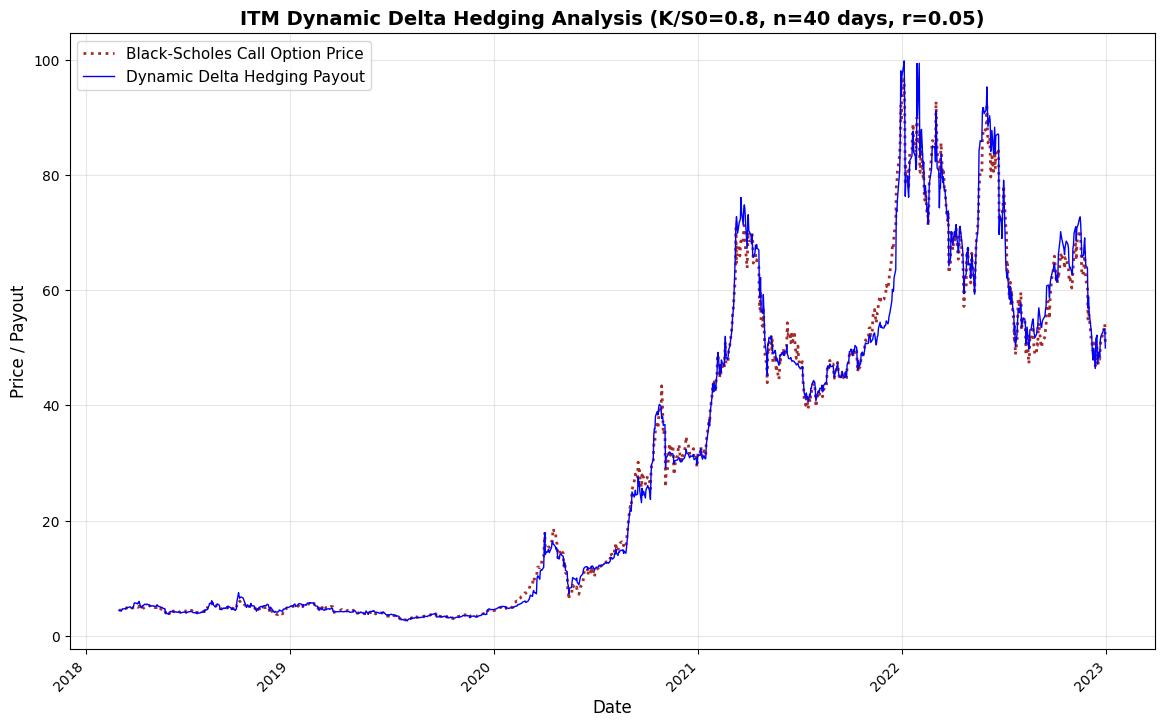

Dynamic Delta Hedging Analysis (K/S0=0.8, n=40 days, r=0.05)
Date range: 2018-03-01 to 2022-12-30

                Close  Discounted_Payout  Call_Price  DDH_Payout  MD_Payout  \
2018-03-01  22.062000           4.927801    4.505717    4.439895   4.342314   
2018-03-02  22.341333           5.378478    4.459634    4.394587   4.197809   
2018-03-05  22.223333           5.400568    4.422251    4.358641   4.150256   
2018-03-06  21.879999           4.956241    4.451934    4.390681   4.277569   
2018-03-07  22.153334           4.178175    4.700879    4.682938   4.783891   

            LD_Payout  
2018-03-01   4.537476  
2018-03-02   4.591365  
2018-03-05   4.567027  
2018-03-06   4.503793  
2018-03-07   4.581986  

Summary statistics:
             Close  Discounted_Payout   Call_Price   DDH_Payout    MD_Payout  \
count  1219.000000        1219.000000  1219.000000  1219.000000  1219.000000   
mean    135.371571          33.330164    29.874538    29.978312    29.307941   
std     118.051053   

In [25]:
# Plot
fig, ax = plt.subplots(figsize=(14, 8))
 
# Plot three curves 
#ax.plot(tsla_ddh_analysis.index, tsla_ddh_analysis['Discounted_Payout'], 
#        linewidth=1, label='Call Option Payout Discounted', color='green')

ax.plot(tsla_ddh_analysis.index, tsla_ddh_analysis['Call_Price'], 
        linewidth=2, label='Black-Scholes Call Option Price', color='brown', linestyle=':')

ax.plot(tsla_ddh_analysis.index, tsla_ddh_analysis['DDH_Payout'], 
        linewidth=1, label='Dynamic Delta Hedging Payout', color='blue')

#ax.plot(tsla_ddh_analysis.index, tsla_ddh_analysis['MD_Payout'], 
#        linewidth=1, label='More Hedging', color='blue', linestyle=':')

#ax.plot(tsla_ddh_analysis.index, tsla_ddh_analysis['LD_Payout'], 
#        linewidth=1, label='Less Hedging', color='blue', linestyle='--')
 
# Labels and formatting
ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Price / Payout', fontsize=12)
ax.set_title(f'ITM Dynamic Delta Hedging Analysis (K/S0={k}, n={n} days, r={r})', 
             fontsize=14, fontweight='bold')
ax.legend(fontsize=11, loc='best')
ax.grid(True, alpha=0.3)

plt.xticks(rotation=45, ha='right')
 
plt.show()
 
# Print summary
print(f"Dynamic Delta Hedging Analysis (K/S0={k}, n={n} days, r={r})")
print(f"Date range: {tsla_ddh_analysis.index[0]} to {tsla_ddh_analysis.index[-1]}")
print(f"\n{tsla_ddh_analysis.head()}")
print(f"\nSummary statistics:")
print(tsla_ddh_analysis.describe())
 

**Summary**

We examine the three scenarios with different strike/price ratios: 
- ATM with $K/S_0 = 1.0$, 
- OTM with an example $K/S_0 = 1.2$, 
- ITM with an example $K/S_0 = 0.8$.

We observe that the payouts of the Dynamic Delta Hedging follow closely the Black-Scholes call option prices using Historical Volatility. This observation suggests the following interpretations:
1. The call option pricing formula is model independent and can be hedged pretty well by Dynamic Delta Hedging.
2. The Historical Volatility (2-month windows) give a good enough approximation of the true volatility when computing the call option prices with 2-month maturity.


## 4. Implied Volatility

In the Black-Scholes Pricing formula $c=c(S_0, K, T, r, \sigma)$, $\sigma$ is the undetermined variable. The market price of the call options can be used to solve for the unknown parameter $\sigma$, which is called the Implied Volatility.  

In [26]:
def bs_call_iv(
    market_prices, #vector
    spots, #vector
    strikes, #vector
    ttes, #vector: time to expirations
    r, #risk-free interest rate
    sigma0 = .2, #initial value guessed
    max_iter = 100, #max number of iterates in case of slow convergence
    tol = 1e-8, #tolerance of errors
    vega_floor = 1e-6, # Newton's method is ineffective if the derivative (vega) is too small
    sigma_lo0 = .05, #lower bounds for sigma
    sigma_hi0 = 8): #upper bounds for sigma
 
    data_length = len(market_prices)
 
    sigmas = np.full(data_length, sigma0, dtype='float')
    sigmas_lo = np.full(data_length, sigma_lo0, dtype='float')
    sigmas_hi = np.full(data_length, sigma_hi0, dtype='float')
    converged = np.zeros(data_length, dtype=bool)
 
    lower = spots - np.exp(-r*ttes)*strikes 
    upper = spots 
    # if a call price is lower than S_0-e^{-rt}K, then one can long a call and short a share.
    # if a call price is higher than S_0, then one can short a call and long a share.
    # so the call prices are valid only between lower and upper.
    valid = (market_prices > lower) & (market_prices < upper)
 
    sigmas[~valid] = np.nan
    # no need (and impossible) to solve the invalid ones
 
    for _ in range(max_iter):
        active = (valid) & (~converged)
 
        if not np.any(active):
            break
 
        active_indexes = np.where(active)[0]
 
        # Extract active data either in the initial setting or returned from the previous step
        # at each step, the length of active data gets shorter.
        # After the write-back, the lengths of the sigmas, converged stay the same.
        market_prices_a = market_prices[active_indexes]
        spots_a = spots[active_indexes]
        strikes_a = strikes[active_indexes]
        sigmas_a = sigmas[active_indexes]
        ttes_a = ttes[active_indexes]
        
        call_option = CallOptionBS(spots_a, strikes_a, ttes_a, r, sigmas_a)
 
        # Compute prices and errors
        bs_prices = call_option.price()
        errors = bs_prices - market_prices_a
 
        # Check convergence
        just_converged = np.abs(errors) < tol
        converged[active_indexes[just_converged]] = True
 
        # Update active set (some may have converged, only the rest need more iterations)
        active = (valid) & (~converged)
        active_indexes = np.where(active)[0]
 
        if not np.any(active):
            break
 
        # Re-extract for non-converged points and prepare for the next step
        market_prices_a = market_prices[active_indexes]
        spots_a = spots[active_indexes]
        strikes_a = strikes[active_indexes]
        sigmas_a = sigmas[active_indexes]
        ttes_a = ttes[active_indexes]
 
        # Recalculate for the updated active set
        call_option = CallOptionBS(spots_a, strikes_a, ttes_a, r, sigmas_a)
        bs_prices = call_option.price()
        errors = bs_prices - market_prices_a
 
        # Update bounds and compute Newton step
        new_lows = errors < 0
        new_highs = errors > 0
 
        sigmas_lo[active_indexes] = np.where(new_lows, sigmas_a, sigmas_lo[active_indexes])
        # np.where(condition, x, y): where condition is true, pick from x; otherwise pick from y
        sigmas_hi[active_indexes] = np.where(new_highs, sigmas_a, sigmas_hi[active_indexes])
        # the lengths stay the same.
 
        vegas = call_option.vega()
 
        sigmas_newton = sigmas_a - errors / np.maximum(vegas, vega_floor)
        sigmas_mid = (sigmas_lo[active_indexes] + sigmas_hi[active_indexes]) * 0.5
 
        bad_newtons = (vegas < vega_floor) | (sigmas_newton < sigmas_lo[active_indexes]) | (sigmas_newton > sigmas_hi[active_indexes])
 
        sigmas[active_indexes] = np.where(bad_newtons, sigmas_mid, sigmas_newton)
 
    sigmas[~converged] = np.nan
 
    return sigmas, converged
 

In [27]:
# 1. Generate synthetic market prices (using true volatilities)
# Underlying parameters
spot = 100
r = 0.05  # 5% risk-free rate
 
# Create 5 call options with different strikes and maturities
# and known true volatilities
true_sigmas = np.array([0.15, 0.20, 0.25, 0.30, 0.35])  # True volatilities
strikes = np.array([95, 100, 105, 110, 100])             # Strike prices
ttes = np.array([0.25, 0.25, 0.25, 0.25, 0.50])          # Time to expiration (years)
spots = np.full(5, spot)                                  # All same spot price
 
# Generate market prices using the true volatilities
print(f"   Spot Price: {spot}")
print(f"   Risk-free Rate: {r}")
print()
 
market_prices = CallOptionBS(spots, strikes, ttes, r, true_sigmas).price()
 
# Display the synthetic data
data_df = np.column_stack((strikes, ttes, true_sigmas, market_prices))
print(f"{'Strike':<10} {'T (years)':<12} {'True σ':<10} {'Market Price':<15}")
print("-" * 50)
for i, row in enumerate(data_df):
    print(f"{row[0]:<10.0f} {row[1]:<12.2f} {row[2]:<10.2f} {row[3]:<15.6f}")

   Spot Price: 100
   Risk-free Rate: 0.05

Strike     T (years)    True σ     Market Price   
--------------------------------------------------
95         0.25         0.15       6.977838       
100        0.25         0.20       4.614997       
105        0.25         0.25       3.439894       
110        0.25         0.30       2.844406       
100        0.50         0.35       11.010434      


In [28]:
# Step 2: Recover implied volatilities from market prices

implied_sigmas, converged = bs_call_iv(
    market_prices=market_prices,
    spots=spots,
    strikes=strikes,
    ttes=ttes,
    r=r,
    sigma0=0.20,      # initial guess
    max_iter=100,
    tol=1e-8
)
 
# Display results
print(f"\n{'Strike':<10} {'T (years)':<12} {'True σ':<10} {'Implied σ':<12} {'Converged':<12} {'Error':<12}")
print("-" * 70)
for i in range(len(strikes)):
    error = abs(implied_sigmas[i] - true_sigmas[i]) if converged[i] else np.nan
    print(f"{strikes[i]:<10.0f} {ttes[i]:<12.2f} {true_sigmas[i]:<10.4f} {implied_sigmas[i]:<12.4f} {str(converged[i]):<12} {error:<12.8f}")
 
print(f"\nConvergence rate: {np.sum(converged)}/{len(converged)}")
print(f"Max error: {np.nanmax(np.abs(implied_sigmas[converged] - true_sigmas[converged])):.2e}")


Strike     T (years)    True σ     Implied σ    Converged    Error       
----------------------------------------------------------------------
95         0.25         0.1500     0.1500       True         0.00000000  
100        0.25         0.2000     0.2000       True         0.00000000  
105        0.25         0.2500     0.2500       True         0.00000000  
110        0.25         0.3000     0.3000       True         0.00000000  
100        0.50         0.3500     0.3500       True         0.00000000  

Convergence rate: 5/5
Max error: 9.16e-16


### 4.1 Implied Volatility of TSLA
The dataset TSLA was uploaded to Kaggle by Kyle Graupe in 2023.

In [29]:
tsla_hist_option = pd.read_csv('tsla_2019_2022.csv', low_memory=False)
tsla_hist_option.columns

Index(['[QUOTE_UNIXTIME]', ' [QUOTE_READTIME]', ' [QUOTE_DATE]',
       ' [QUOTE_TIME_HOURS]', ' [UNDERLYING_LAST]', ' [EXPIRE_DATE]',
       ' [EXPIRE_UNIX]', ' [DTE]', ' [C_DELTA]', ' [C_GAMMA]', ' [C_VEGA]',
       ' [C_THETA]', ' [C_RHO]', ' [C_IV]', ' [C_VOLUME]', ' [C_LAST]',
       ' [C_SIZE]', ' [C_BID]', ' [C_ASK]', ' [STRIKE]', ' [P_BID]',
       ' [P_ASK]', ' [P_SIZE]', ' [P_LAST]', ' [P_DELTA]', ' [P_GAMMA]',
       ' [P_VEGA]', ' [P_THETA]', ' [P_RHO]', ' [P_IV]', ' [P_VOLUME]',
       ' [STRIKE_DISTANCE]', ' [STRIKE_DISTANCE_PCT]'],
      dtype='object')

In [30]:
tsla_hist_option.columns = tsla_hist_option.columns.str.strip()
tsla_hist_option.columns

Index(['[QUOTE_UNIXTIME]', '[QUOTE_READTIME]', '[QUOTE_DATE]',
       '[QUOTE_TIME_HOURS]', '[UNDERLYING_LAST]', '[EXPIRE_DATE]',
       '[EXPIRE_UNIX]', '[DTE]', '[C_DELTA]', '[C_GAMMA]', '[C_VEGA]',
       '[C_THETA]', '[C_RHO]', '[C_IV]', '[C_VOLUME]', '[C_LAST]', '[C_SIZE]',
       '[C_BID]', '[C_ASK]', '[STRIKE]', '[P_BID]', '[P_ASK]', '[P_SIZE]',
       '[P_LAST]', '[P_DELTA]', '[P_GAMMA]', '[P_VEGA]', '[P_THETA]',
       '[P_RHO]', '[P_IV]', '[P_VOLUME]', '[STRIKE_DISTANCE]',
       '[STRIKE_DISTANCE_PCT]'],
      dtype='object')

In [31]:
tsla_hist_option.head()

,[QUOTE_UNIXTIME],[QUOTE_READTIME],[QUOTE_DATE],[QUOTE_TIME_HOURS],[UNDERLYING_LAST],[EXPIRE_DATE],[EXPIRE_UNIX],[DTE],[C_DELTA],[C_GAMMA],...,[P_LAST],[P_DELTA],[P_GAMMA],[P_VEGA],[P_THETA],[P_RHO],[P_IV],[P_VOLUME],[STRIKE_DISTANCE],[STRIKE_DISTANCE_PCT]
0,1556740800,2019-05-01 16:00,2019-05-01,16.0,233.98,2019-05-03,1556913600,2.0,0.984650,0.000550,...,0.010000,-0.000710,0.000030,0.000460,-0.009750,0.000000,2.225480,147.000000,104.0,0.444
1,1556740800,2019-05-01 16:00,2019-05-01,16.0,233.98,2019-05-03,1556913600,2.0,0.983710,0.000670,...,0.020000,-0.001090,0.000090,0.000580,-0.010100,-0.000010,2.083490,12.000000,99.0,0.423
2,1556740800,2019-05-01 16:00,2019-05-01,16.0,233.98,2019-05-03,1556913600,2.0,0.984580,0.000690,...,0.020000,-0.001220,0.000120,0.001130,-0.014350,0.000000,2.023590,15.000000,94.0,0.402
3,1556740800,2019-05-01 16:00,2019-05-01,16.0,233.98,2019-05-03,1556913600,2.0,0.991870,0.000490,...,0.010000,-0.001340,0.000090,0.001390,-0.014650,0.000000,1.895040,0.000000,89.0,0.380
4,1556740800,2019-05-01 16:00,2019-05-01,16.0,233.98,2019-05-03,1556913600,2.0,0.993410,0.000390,...,0.010000,-0.001760,0.000080,0.001050,-0.014670,0.000000,1.768120,91.000000,84.0,0.359


In [32]:
tsla_hist_option.tail()

,[QUOTE_UNIXTIME],[QUOTE_READTIME],[QUOTE_DATE],[QUOTE_TIME_HOURS],[UNDERLYING_LAST],[EXPIRE_DATE],[EXPIRE_UNIX],[DTE],[C_DELTA],[C_GAMMA],...,[P_LAST],[P_DELTA],[P_GAMMA],[P_VEGA],[P_THETA],[P_RHO],[P_IV],[P_VOLUME],[STRIKE_DISTANCE],[STRIKE_DISTANCE_PCT]
2659254,1567195200,2019-08-30 16:00,2019-08-30,16.0,225.6,2021-06-18,1624046400,658.0,0.183030,0.002020,...,0.000000,-0.965400,0.000000,0.000000,-0.011600,-7.753380,0.000040,,204.4,0.906
2659255,1567195200,2019-08-30 16:00,2019-08-30,16.0,225.6,2021-06-18,1624046400,658.0,0.178260,0.001930,...,0.000000,-0.965240,0.000000,0.000000,-0.011450,-7.843780,0.000220,,209.4,0.928
2659256,1567195200,2019-08-30 16:00,2019-08-30,16.0,225.6,2021-06-18,1624046400,658.0,0.179540,0.001920,...,0.000000,-0.965650,0.000000,0.000000,-0.011900,-7.934310,0.000300,,214.4,0.950
2659257,1567195200,2019-08-30 16:00,2019-08-30,16.0,225.6,2021-06-18,1624046400,658.0,0.162070,0.001910,...,0.000000,-1.000000,0.000000,77.279150,0.000000,0.000000,0.000370,,219.4,0.973
2659258,1567195200,2019-08-30 16:00,2019-08-30,16.0,225.6,2021-06-18,1624046400,658.0,0.164460,0.001840,...,0.000000,-1.000000,0.000000,77.269950,0.000000,0.000000,0.000220,,224.4,0.995


In [33]:
call_data = tsla_hist_option[
    ['[QUOTE_DATE]', '[UNDERLYING_LAST]', '[STRIKE]', '[EXPIRE_DATE]',
     '[DTE]', '[C_SIZE]', '[C_BID]', '[C_ASK]', '[STRIKE_DISTANCE_PCT]']
].copy()

call_data['tte'] = call_data['[DTE]'] / 365
call_data['[QUOTE_DATE]'] = call_data['[QUOTE_DATE]'].str.strip()
call_data['[EXPIRE_DATE]'] = call_data['[EXPIRE_DATE]'].str.strip()
call_data['[C_BID]'] = pd.to_numeric(call_data['[C_BID]'].str.strip(), errors='coerce')
call_data['[C_ASK]'] = pd.to_numeric(call_data['[C_ASK]'].str.strip(), errors='coerce')

In [34]:
call_data.head()

,[QUOTE_DATE],[UNDERLYING_LAST],[STRIKE],[EXPIRE_DATE],[DTE],[C_SIZE],[C_BID],[C_ASK],[STRIKE_DISTANCE_PCT],tte
0,2019-05-01,233.98,130.0,2019-05-03,2.0,30 x 30,103.60,105.20,0.444,0.005479
1,2019-05-01,233.98,135.0,2019-05-03,2.0,52 x 52,98.41,100.39,0.423,0.005479
2,2019-05-01,233.98,140.0,2019-05-03,2.0,30 x 10,93.45,95.20,0.402,0.005479
3,2019-05-01,233.98,145.0,2019-05-03,2.0,30 x 30,87.70,90.55,0.380,0.005479
4,2019-05-01,233.98,150.0,2019-05-03,2.0,10 x 10,82.95,85.19,0.359,0.005479


In [35]:
call_data.tail()

,[QUOTE_DATE],[UNDERLYING_LAST],[STRIKE],[EXPIRE_DATE],[DTE],[C_SIZE],[C_BID],[C_ASK],[STRIKE_DISTANCE_PCT],tte
2659254,2019-08-30,225.6,430.0,2021-06-18,658.0,52 x 44,8.49,11.99,0.906,1.80274
2659255,2019-08-30,225.6,435.0,2021-06-18,658.0,52 x 62,8.09,11.75,0.928,1.80274
2659256,2019-08-30,225.6,440.0,2021-06-18,658.0,39 x 34,8.00,12.30,0.950,1.80274
2659257,2019-08-30,225.6,445.0,2021-06-18,658.0,39 x 25,7.30,10.20,0.973,1.80274
2659258,2019-08-30,225.6,450.0,2021-06-18,658.0,21 x 21,8.06,10.06,0.995,1.80274


In [36]:
call_data[['bid_size', 'ask_size']] = (call_data['[C_SIZE]'].str.strip().str.split('x', expand=True).astype(int))

#Market mid prices
call_data['c_mid'] = ( call_data['[C_BID]'] + call_data['[C_ASK]'] ) / (2)

call_data['c_mid_weighted'] = (call_data['bid_size']*call_data['[C_BID]']\
                                    + call_data['ask_size']*call_data['[C_ASK]'])/(call_data['bid_size'] + call_data['ask_size'])

In [37]:
call_data_5 = call_data[(call_data['tte']>.1)& \
    (call_data['[STRIKE_DISTANCE_PCT]'] <.5) &\
    (call_data['tte']<1/2) &\
    (call_data['bid_size'] >5) &\
    (call_data['ask_size'] >5)].copy()

In [38]:
call_data_5

,[QUOTE_DATE],[UNDERLYING_LAST],[STRIKE],[EXPIRE_DATE],[DTE],[C_SIZE],[C_BID],[C_ASK],[STRIKE_DISTANCE_PCT],tte,bid_size,ask_size,c_mid,c_mid_weighted
404,2019-05-01,233.98,180.0,2019-06-07,37.00,30 x 22,54.91,59.31,0.231,0.101370,30,22,57.110,56.771538
405,2019-05-01,233.98,185.0,2019-06-07,37.00,34 x 34,50.55,54.60,0.209,0.101370,34,34,52.575,52.575000
406,2019-05-01,233.98,190.0,2019-06-07,37.00,34 x 34,46.20,50.51,0.188,0.101370,34,34,48.355,48.355000
407,2019-05-01,233.98,195.0,2019-06-07,37.00,38 x 30,41.69,44.85,0.167,0.101370,38,30,43.270,43.084118
408,2019-05-01,233.98,200.0,2019-06-07,37.00,30 x 30,39.34,40.25,0.145,0.101370,30,30,39.795,39.795000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2658882,2019-08-30,225.60,315.0,2020-01-17,140.04,101 x 119,3.49,3.90,0.396,0.383671,101,119,3.695,3.711773
2658883,2019-08-30,225.60,320.0,2020-01-17,140.04,114 x 95,3.06,3.41,0.418,0.383671,114,95,3.235,3.219091
2658884,2019-08-30,225.60,325.0,2020-01-17,140.04,99 x 128,2.69,3.05,0.441,0.383671,99,128,2.870,2.892996
2658885,2019-08-30,225.60,330.0,2020-01-17,140.04,105 x 107,2.37,2.66,0.463,0.383671,105,107,2.515,2.516368


In [39]:

call_data_day = call_data[(call_data['tte']>.1)& \
    (call_data['[STRIKE_DISTANCE_PCT]'] <.5) &\
    (call_data['tte']<1/2) &\
    (call_data['[EXPIRE_DATE]'] == '2021-06-18') &\
    (call_data['bid_size'] >5) &\
    (call_data['ask_size'] >5)].copy()

In [40]:
len(call_data_day)

2645

In [41]:
call_data_day.head()

,[QUOTE_DATE],[UNDERLYING_LAST],[STRIKE],[EXPIRE_DATE],[DTE],[C_SIZE],[C_BID],[C_ASK],[STRIKE_DISTANCE_PCT],tte,bid_size,ask_size,c_mid,c_mid_weighted
886721,2020-12-21,649.78,328.0,2021-06-18,178.96,29 x 50,329.94,332.60,0.495,0.490301,29,50,331.270,331.623544
886724,2020-12-21,649.78,334.0,2021-06-18,178.96,11 x 17,325.05,326.61,0.486,0.490301,11,17,325.830,325.997143
886729,2020-12-21,649.78,344.0,2021-06-18,178.96,50 x 32,315.45,318.59,0.471,0.490301,50,32,317.020,316.675366
886730,2020-12-21,649.78,345.0,2021-06-18,178.96,34 x 50,314.70,317.85,0.469,0.490301,34,50,316.275,316.575000
886731,2020-12-21,649.78,346.0,2021-06-18,178.96,50 x 50,313.65,317.26,0.468,0.490301,50,50,315.455,315.455000


In [42]:
#Find implied volatilities using c_mid
iv,converges = bs_call_iv(call_data_day['c_mid'].values, 
                     call_data_day['[UNDERLYING_LAST]'].values,
                     call_data_day['[STRIKE]'].values,
                     call_data_day['tte'].values,
                     .039)

call_data_day['IV'] = iv
call_data_day = call_data_day.dropna().copy()

In [43]:
#Find implied volatilities using c_mid_weighted
iv_w,converges_w = bs_call_iv(call_data_day['c_mid_weighted'].values, 
                     call_data_day['[UNDERLYING_LAST]'].values,
                     call_data_day['[STRIKE]'].values,
                     call_data_day['tte'].values,
                     .039)

call_data_day['IV_W'] = iv_w
call_data_day = call_data_day.dropna().copy()

In [44]:
df = call_data_day[call_data_day["[QUOTE_DATE]"]=="2021-04-19"]
df

,[QUOTE_DATE],[UNDERLYING_LAST],[STRIKE],[EXPIRE_DATE],[DTE],[C_SIZE],[C_BID],[C_ASK],[STRIKE_DISTANCE_PCT],tte,bid_size,ask_size,c_mid,c_mid_weighted,IV,IV_W
1873187,2021-04-19,714.63,545.0,2021-06-18,60.0,14 x 6,184.80,186.35,0.237,0.164384,14,6,185.575,185.265000,0.653230,0.647827
1873191,2021-04-19,714.63,580.0,2021-06-18,60.0,14 x 6,156.95,158.41,0.188,0.164384,14,6,157.680,157.388000,0.645864,0.641879
1873194,2021-04-19,714.63,610.0,2021-06-18,60.0,11 x 7,134.85,136.34,0.146,0.164384,11,7,135.595,135.429444,0.639793,0.637873
1873200,2021-04-19,714.63,670.0,2021-06-18,60.0,7 x 7,96.50,97.54,0.062,0.164384,7,7,97.020,97.020000,0.627714,0.627714
1873201,2021-04-19,714.63,680.0,2021-06-18,60.0,10 x 9,90.74,91.80,0.048,0.164384,10,9,91.270,91.242105,0.624965,0.624709
1873202,2021-04-19,714.63,690.0,2021-06-18,60.0,11 x 7,85.31,86.29,0.034,0.164384,11,7,85.800,85.691111,0.622786,0.621803
1873205,2021-04-19,714.63,720.0,2021-06-18,60.0,9 x 6,70.29,71.15,0.008,0.164384,9,6,70.720,70.634000,0.616407,0.615658
1873206,2021-04-19,714.63,730.0,2021-06-18,60.0,6 x 8,65.75,66.55,0.022,0.164384,6,8,66.150,66.207143,0.614488,0.614984
1873207,2021-04-19,714.63,740.0,2021-06-18,60.0,11 x 6,61.40,62.24,0.035,0.164384,11,6,61.820,61.696471,0.612806,0.611737
1873208,2021-04-19,714.63,750.0,2021-06-18,60.0,6 x 8,57.29,58.10,0.049,0.164384,6,8,57.695,57.752857,0.611086,0.611587


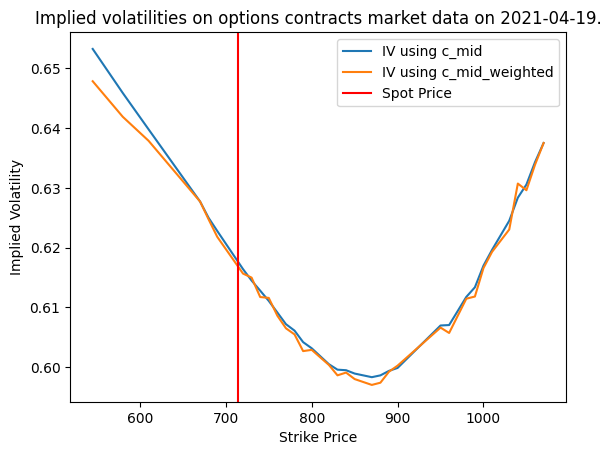

In [45]:
date = "2021-04-19"

plt.plot(df['[STRIKE]'].values, df['IV'].values, label="IV using c_mid") 
plt.plot(df['[STRIKE]'].values, df['IV_W'].values, label="IV using c_mid_weighted") 
plt.axvline(df['[UNDERLYING_LAST]'].values[0], color='red', label='Spot Price')
plt.title(f'Implied volatilities on options contracts market data on {date}.')
plt.xlabel('Strike Price')
plt.ylabel('Implied Volatility')
plt.legend()
plt.show()

### 4.2 Historical Volatility vs Implied Volatility
 
Previously the hv is computed using rolling windows of two months. Now we restrict ourselves to the call options with expiration time T=2/12. Since options only matures on Fridays, we need to find, for any given day, the time-to-expiration to the next Friday after two months. We use them as lower and upper bounds to filter the call options. 

In [46]:
# Given starting day
start_day = pd.to_datetime('2020-12-18')

# Get 7 consecutive days
tte_values = []
dates = []

for i in range(28):
    current_day = start_day + timedelta(days=i)
    # Find the Friday two months away
    target_date = current_day + timedelta(days=60)  # Approximately 2 months
    # Find the next Friday
    days_until_friday = (4 - target_date.weekday()) % 7  # 4 = Friday
    if days_until_friday == 0 and target_date.weekday() == 4:
        friday_two_months = target_date
    else:
        friday_two_months = target_date + timedelta(days=days_until_friday)
    tte = (friday_two_months - current_day).days / 365  # Days elapsed / 365
    tte_values.append(tte)
    dates.append(current_day)

In [47]:
tte_days = pd.DataFrame({
    'Date': dates,
    'TTE': tte_values
})

print(tte_days)

         Date       TTE
0  2020-12-18  0.172603
1  2020-12-19  0.169863
2  2020-12-20  0.167123
3  2020-12-21  0.164384
4  2020-12-22  0.180822
5  2020-12-23  0.178082
6  2020-12-24  0.175342
7  2020-12-25  0.172603
8  2020-12-26  0.169863
9  2020-12-27  0.167123
10 2020-12-28  0.164384
11 2020-12-29  0.180822
12 2020-12-30  0.178082
13 2020-12-31  0.175342
14 2021-01-01  0.172603
15 2021-01-02  0.169863
16 2021-01-03  0.167123
17 2021-01-04  0.164384
18 2021-01-05  0.180822
19 2021-01-06  0.178082
20 2021-01-07  0.175342
21 2021-01-08  0.172603
22 2021-01-09  0.169863
23 2021-01-10  0.167123
24 2021-01-11  0.164384
25 2021-01-12  0.180822
26 2021-01-13  0.178082
27 2021-01-14  0.175342


In [48]:
call_data_2 = call_data[(call_data['tte']>.162)& \
    (call_data['tte']<.185) &\
    (call_data['bid_size'] >2) &\
    (call_data['ask_size'] >2)].copy()

In [49]:
call_data_2

,[QUOTE_DATE],[UNDERLYING_LAST],[STRIKE],[EXPIRE_DATE],[DTE],[C_SIZE],[C_BID],[C_ASK],[STRIKE_DISTANCE_PCT],tte,bid_size,ask_size,c_mid,c_mid_weighted
11058,2019-05-13,227.03,10.0,2019-07-19,67.0,10 x 10,215.80,218.46,0.956,0.183562,10,10,217.130,217.130000
11059,2019-05-13,227.03,15.0,2019-07-19,67.0,10 x 10,210.80,213.45,0.934,0.183562,10,10,212.125,212.125000
11060,2019-05-13,227.03,20.0,2019-07-19,67.0,10 x 10,205.80,208.45,0.912,0.183562,10,10,207.125,207.125000
11061,2019-05-13,227.03,25.0,2019-07-19,67.0,10 x 10,200.60,203.40,0.890,0.183562,10,10,202.000,202.000000
11062,2019-05-13,227.03,30.0,2019-07-19,67.0,10 x 10,195.59,198.45,0.868,0.183562,10,10,197.020,197.020000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2648886,2019-08-19,226.83,375.0,2019-10-18,60.0,70 x 54,0.01,0.15,0.653,0.164384,70,54,0.080,0.070968
2648887,2019-08-19,226.83,380.0,2019-10-18,60.0,52 x 60,0.02,0.13,0.675,0.164384,52,60,0.075,0.078929
2648888,2019-08-19,226.83,385.0,2019-10-18,60.0,30 x 37,0.01,0.13,0.697,0.164384,30,37,0.070,0.076269
2648889,2019-08-19,226.83,390.0,2019-10-18,60.0,12 x 53,0.01,0.12,0.719,0.164384,12,53,0.065,0.099692


In [50]:
iv,converges = bs_call_iv(call_data_2['c_mid'].values, 
                     call_data_2['[UNDERLYING_LAST]'].values,
                     call_data_2['[STRIKE]'].values,
                     call_data_2['tte'].values,
                     .039)

call_data_2['IV'] = iv
call_data_2['IV_converged'] = converges
call_data_2 = call_data_2.dropna().copy()

In [51]:
call_data_2

,[QUOTE_DATE],[UNDERLYING_LAST],[STRIKE],[EXPIRE_DATE],[DTE],[C_SIZE],[C_BID],[C_ASK],[STRIKE_DISTANCE_PCT],tte,bid_size,ask_size,c_mid,c_mid_weighted,IV,IV_converged
11058,2019-05-13,227.03,10.0,2019-07-19,67.0,10 x 10,215.80,218.46,0.956,0.183562,10,10,217.130,217.130000,2.556432,True
11080,2019-05-13,227.03,120.0,2019-07-19,67.0,10 x 10,106.65,109.25,0.471,0.183562,10,10,107.950,107.950000,0.583589,True
11081,2019-05-13,227.03,125.0,2019-07-19,67.0,10 x 10,101.95,104.55,0.449,0.183562,10,10,103.250,103.250000,0.677079,True
11082,2019-05-13,227.03,130.0,2019-07-19,67.0,52 x 52,97.00,99.56,0.427,0.183562,52,52,98.280,98.280000,0.635867,True
11083,2019-05-13,227.03,135.0,2019-07-19,67.0,52 x 52,92.19,94.75,0.405,0.183562,52,52,93.470,93.470000,0.635897,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2648886,2019-08-19,226.83,375.0,2019-10-18,60.0,70 x 54,0.01,0.15,0.653,0.164384,70,54,0.080,0.070968,0.470234,True
2648887,2019-08-19,226.83,380.0,2019-10-18,60.0,52 x 60,0.02,0.13,0.675,0.164384,52,60,0.075,0.078929,0.477793,True
2648888,2019-08-19,226.83,385.0,2019-10-18,60.0,30 x 37,0.01,0.13,0.697,0.164384,30,37,0.070,0.076269,0.484893,True
2648889,2019-08-19,226.83,390.0,2019-10-18,60.0,12 x 53,0.01,0.12,0.719,0.164384,12,53,0.065,0.099692,0.491512,True


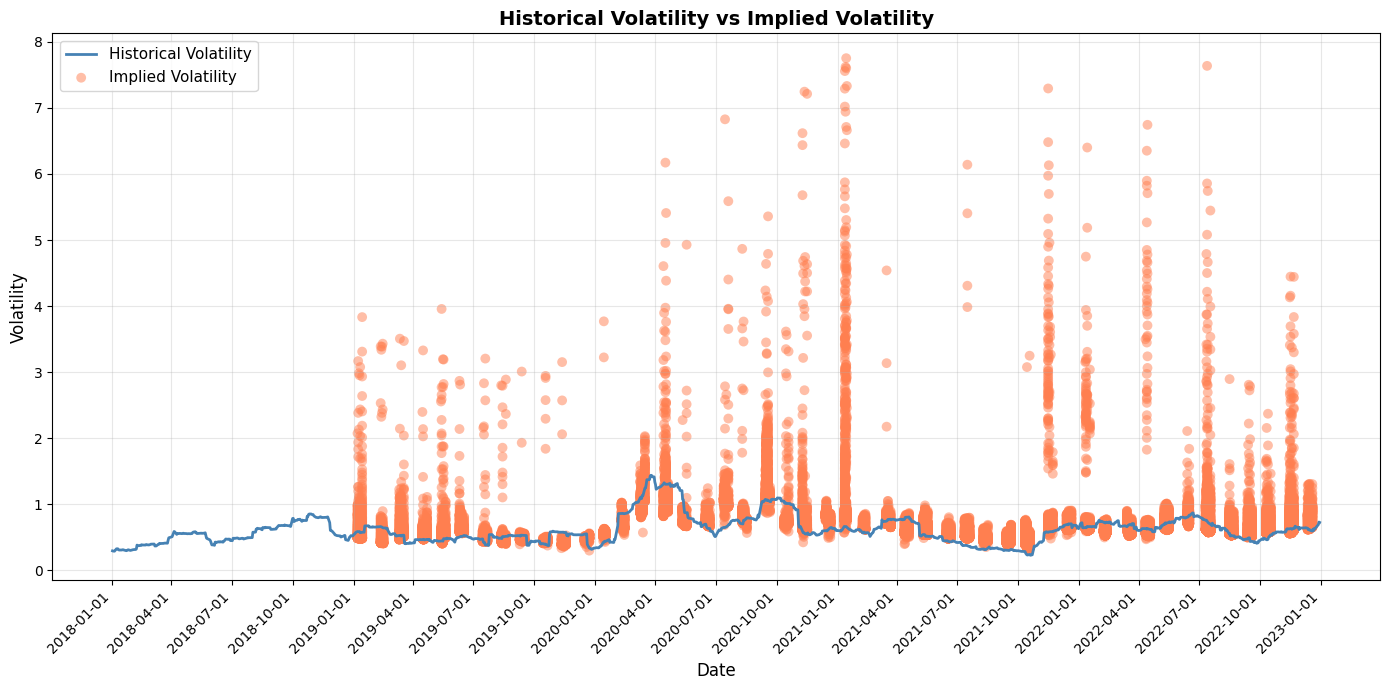

In [52]:
# Reset index to make it a regular column if needed
call_data_2_reset = call_data_2.reset_index(drop=True)

# Or convert QUOTE_DATE to datetime and set it as index
call_data_2['[QUOTE_DATE]'] = pd.to_datetime(call_data_2['[QUOTE_DATE]'])
call_data_2_indexed = call_data_2.set_index('[QUOTE_DATE]')

# Now plot
fig, ax = plt.subplots(figsize=(14, 7))

# Plot HV curve
ax.plot(hv_filtered.index, hv_filtered.values, 
        linewidth=2, label='Historical Volatility', color='steelblue')

# Plot IV scatter using datetime index
iv_dates = call_data_2['[QUOTE_DATE]']
iv_values = call_data_2['IV']

ax.scatter(iv_dates, iv_values, 
          alpha=0.5, s=50, label='Implied Volatility', color='coral', edgecolors='none')

ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Volatility', fontsize=12)
ax.set_title('Historical Volatility vs Implied Volatility', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

import matplotlib.dates as mdates
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

We observe the accumulation of Implied Volatility of call options around the curve of Historical Volatility. We suspect that these are the At-The-Money calls. Next, we will select only these calls.

In [53]:
call_data_atm2 = call_data_2[call_data_2['[STRIKE]'] >= call_data_2['[UNDERLYING_LAST]']].copy()
call_data_atm2 = call_data_atm2.loc[call_data_atm2.groupby('[QUOTE_DATE]')['[STRIKE]'].idxmin()]
call_data_atm2

,[QUOTE_DATE],[UNDERLYING_LAST],[STRIKE],[EXPIRE_DATE],[DTE],[C_SIZE],[C_BID],[C_ASK],[STRIKE_DISTANCE_PCT],tte,bid_size,ask_size,c_mid,c_mid_weighted,IV,IV_converged
1541475,2019-01-07,334.97,345.0,2019-03-15,66.96,15 x 42,29.20,29.65,0.030,0.183452,15,42,29.425,29.531579,0.572816,True
1542961,2019-01-08,335.29,340.0,2019-03-15,65.96,21 x 4,31.64,32.10,0.014,0.180712,21,4,31.870,31.713600,0.580133,True
1544463,2019-01-09,338.46,340.0,2019-03-15,64.96,7 x 5,33.25,33.89,0.005,0.177973,7,5,33.570,33.516667,0.584351,True
1546038,2019-01-10,345.00,345.0,2019-03-15,63.96,14 x 28,34.29,34.70,0.000,0.175233,14,28,34.495,34.563333,0.581503,True
1547617,2019-01-11,347.23,355.0,2019-03-15,62.96,7 x 30,29.26,29.66,0.022,0.172493,7,30,29.460,29.584324,0.554588,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1114876,2022-12-12,167.73,170.0,2023-02-17,67.00,20 x 123,18.50,18.60,0.014,0.183562,20,123,18.550,18.586014,0.665478,True
1116621,2022-12-13,160.98,165.0,2023-02-17,66.00,37 x 23,16.80,16.95,0.025,0.180822,37,23,16.875,16.857500,0.665332,True
1118412,2022-12-14,156.86,160.0,2023-02-17,65.00,272 x 54,16.55,16.70,0.020,0.178082,272,54,16.625,16.574847,0.665218,True
1120204,2022-12-15,157.71,160.0,2023-02-17,64.00,291 x 20,16.75,16.90,0.015,0.175342,291,20,16.825,16.759646,0.660736,True


In [54]:
call_data_atm2["[QUOTE_DATE]"].unique()

<DatetimeArray>
['2019-01-07 00:00:00', '2019-01-08 00:00:00', '2019-01-09 00:00:00',
 '2019-01-10 00:00:00', '2019-01-11 00:00:00', '2019-01-14 00:00:00',
 '2019-02-11 00:00:00', '2019-02-12 00:00:00', '2019-02-13 00:00:00',
 '2019-02-14 00:00:00',
 ...
 '2022-11-15 00:00:00', '2022-11-16 00:00:00', '2022-11-17 00:00:00',
 '2022-11-18 00:00:00', '2022-11-21 00:00:00', '2022-12-12 00:00:00',
 '2022-12-13 00:00:00', '2022-12-14 00:00:00', '2022-12-15 00:00:00',
 '2022-12-19 00:00:00']
Length: 275, dtype: datetime64[ns]

In [55]:
#Find implied volatilities
iv2,converges2 = bs_call_iv(call_data_atm2['c_mid'].values, 
                     call_data_atm2['[UNDERLYING_LAST]'].values,
                     call_data_atm2['[STRIKE]'].values,
                     call_data_atm2['tte'].values,
                     .039)

call_data_atm2['IV'] = iv2
call_data_atm2['IV_converged'] = converges2
call_data_atm2 = call_data_atm2.dropna().copy()

In [56]:
call_data_atm2

,[QUOTE_DATE],[UNDERLYING_LAST],[STRIKE],[EXPIRE_DATE],[DTE],[C_SIZE],[C_BID],[C_ASK],[STRIKE_DISTANCE_PCT],tte,bid_size,ask_size,c_mid,c_mid_weighted,IV,IV_converged
1541475,2019-01-07,334.97,345.0,2019-03-15,66.96,15 x 42,29.20,29.65,0.030,0.183452,15,42,29.425,29.531579,0.572816,True
1542961,2019-01-08,335.29,340.0,2019-03-15,65.96,21 x 4,31.64,32.10,0.014,0.180712,21,4,31.870,31.713600,0.580133,True
1544463,2019-01-09,338.46,340.0,2019-03-15,64.96,7 x 5,33.25,33.89,0.005,0.177973,7,5,33.570,33.516667,0.584351,True
1546038,2019-01-10,345.00,345.0,2019-03-15,63.96,14 x 28,34.29,34.70,0.000,0.175233,14,28,34.495,34.563333,0.581503,True
1547617,2019-01-11,347.23,355.0,2019-03-15,62.96,7 x 30,29.26,29.66,0.022,0.172493,7,30,29.460,29.584324,0.554588,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1114876,2022-12-12,167.73,170.0,2023-02-17,67.00,20 x 123,18.50,18.60,0.014,0.183562,20,123,18.550,18.586014,0.665478,True
1116621,2022-12-13,160.98,165.0,2023-02-17,66.00,37 x 23,16.80,16.95,0.025,0.180822,37,23,16.875,16.857500,0.665332,True
1118412,2022-12-14,156.86,160.0,2023-02-17,65.00,272 x 54,16.55,16.70,0.020,0.178082,272,54,16.625,16.574847,0.665218,True
1120204,2022-12-15,157.71,160.0,2023-02-17,64.00,291 x 20,16.75,16.90,0.015,0.175342,291,20,16.825,16.759646,0.660736,True


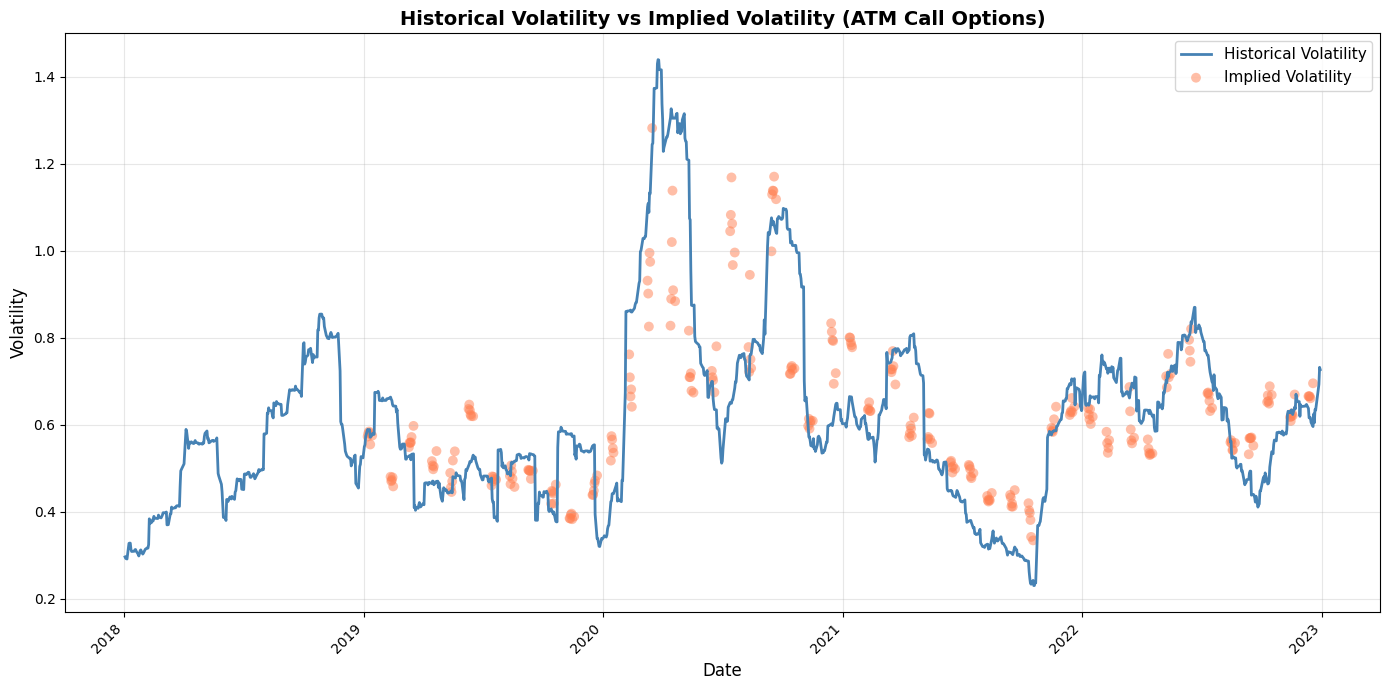

In [57]:
call_data_atm2['[QUOTE_DATE]'] = pd.to_datetime(call_data_atm2['[QUOTE_DATE]'])
call_data_atm2_indexed = call_data_atm2.set_index('[QUOTE_DATE]')

# Now plot
fig, ax = plt.subplots(figsize=(14, 7))

# Plot HV curve
ax.plot(hv_filtered.index, hv_filtered.values, 
        linewidth=2, label='Historical Volatility', color='steelblue')

# Plot IV scatter using datetime index
iv_dates = call_data_atm2['[QUOTE_DATE]']
iv_values = call_data_atm2['IV']

ax.scatter(iv_dates, iv_values, 
          alpha=0.5, s=50, label='Implied Volatility', color='coral', edgecolors='none')

ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Volatility', fontsize=12)
ax.set_title('Historical Volatility vs Implied Volatility (ATM Call Options)', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

We observe that the Implied Volatility of 2-month ATM calls follows closely to the Historical Volatility using the past two-month data.

## 5. Merton Jump Process Model

The Merton model extends Black-Scholes by incorporating jump risk via a Poisson process. The stock price dynamics follow:

$$\ln\left(\frac{S_T}{S_0}\right) = \left(r - \lambda\kappa - \frac{\sigma^2}{2}\right)T + \sigma\sqrt{T}Z + \sum_{i=1}^{Y} X_i,$$

where 

- $r$ is the risk-free interest rate,
- $\sigma$ is the continuous diffusion volatility,
- $Z \sim N(0,1)$ is a standard normal random variable,
- $Y \sim \text{Poisson}(\lambda)$ is the number of jumps over period $[0,T]$,
- $X_i \sim N(\mu_J, \delta_J^2)$ are i.i.d. jump size distributions,
- $\lambda$ is the jump intensity (expected number of jumps per year),
- $\mu_J$ is the expected (log) jump size,
- $\delta_J$ is the jump volatility (standard deviation of log jump size),
- $\kappa = e^{\mu_J + \delta_J^2/2} - 1$ (recall that $E[e^{X}]= e^{\mu_J + \delta_J^2/2} $).

## Intuition

The model decomposes returns into three components:
1. **Drift adjustment**: $(r - \lambda\kappa - \sigma^2/2)T$ accounts for risk-free rate, jump premium, and continuous volatility
2. **Diffusion**: $\sigma\sqrt{T}Z$ is the continuous price movement
3. **Jumps**: $\sum_{i=1}^{Y} X_i$ are discrete discontinuous price movements

## Simplification

Suppose $Y=k$ for some $k\ge 0$. Then 
$$\ln\left(\frac{S_T}{S_0}\right) = \left(r - \lambda\kappa - \frac{\sigma^2}{2}\right)T + k\mu_J + \sqrt{\sigma^2T + k\delta_J^2}Z.$$

Comparing with the Black-Scholes Model $\ln\left(\frac{S_T}{S_0}\right) = \left(r - \frac{\sigma^2}{2}\right)T + \sigma\sqrt{T}Z$, we see that the Merton Jump Process model can be viewed as a Black-Scholes Model with adjusted parameters. More precisely, let $\sigma_k = \sqrt{\sigma^2 + k\delta_J^2/T}$ and $S_k = S_0 e^{-\lambda \kappa T + k\mu_J + k\delta_J^2/2}$. Then 
$$\ln\left(\frac{S_T}{S_k}\right) = \left(r - \frac{\sigma_k^2}{2}\right)T +  \sigma_k\sqrt{T}Z.$$

In particular, the computation of the call options prices for Merton Jump Process model can be reduced to that of Black-Scholes Model:
$$e^{-rT}\hat{E}[(S_T - K)^+ | Y =k] = c_{BS}(S_k, K, T, r, \sigma_k).$$
It follows that
$$c_M(S_0, K, T, r, \sigma, \lambda, \mu_J, \delta_J) = \sum_{k\ge 0} p_k \cdot c_{BS}(S_k, K, T, r, \sigma_k).$$

The formulas for Greeks can be derived in the same way. Note that the Poisson probability $p_k = e^{-\lambda T} \frac{(\lambda T)^k}{k!}$ decays exponentially. So it suffices to use a partial sum approximation, say $k_{\max} = 100$.


In [58]:
class CallOptionMerton:
    """
    European call option pricing using the Merton jump-diffusion model.
    ----------
    S0 : float
        Current stock price
    K : float
        Strike price
    r : float
        Risk-free rate
    s : float
        Volatility of stock returns (diffusion component)
    T : float
        Time to maturity in years
    lam : float
        Jump intensity (average number of jumps per year)
    muJ : float
        Mean jump size (e.g., 0.05 for 5% expected jump)
    deltaJ : float
        Jump volatility (standard deviation of jump magnitude)
    k_max : int, default 100
        Maximum number of jumps for numerical integration
    """
    
    def __init__(self, S0, K, T, r, s, lam, muJ, deltaJ, k_max=100):
        self.S0 = S0
        self.K = K
        self.T = T
        self.r = r
        self.s = s
        self.lam = lam
        self.muJ = muJ
        self.deltaJ = deltaJ
        self.k_max = k_max
        
        # Jump compensator: risk-neutral adjustment for jump risk
        # κ = e^(μ_J + δ_J²/2) - 1
        self.kappa = np.exp(self.muJ + 0.5 * self.deltaJ**2) - 1

    def _bs_call(self, S, K, T, r, sigma):
        """
        Helper method: Black-Scholes call price with given parameters.
        """
        d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
        d2 = d1 - sigma * np.sqrt(T)
        return S * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)

    def price(self):
        """
        Merton jump-diffusion call option price.
        """
        k = np.arange(self.k_max + 1)
        
        # Poisson probabilities: P(N_T = k)
        weights = poisson.pmf(k, self.lam * self.T)
        
        # Adjusted spot prices with jump-compensator drift adjustment
        # S_0k = S_0 * e^(-λκT + k(μ_J + δ_J²/2))
        spots = self.S0 * np.exp(-self.lam * self.kappa * self.T + k * (self.muJ + 0.5 * self.deltaJ**2))
        
        # Effective volatility for each jump scenario
        # σ_k = sqrt(σ² + k*δ_J²/T)
        sigmas = np.sqrt(self.s**2 + (k * self.deltaJ**2) / self.T)
        
        # Black-Scholes prices for each scenario
        bs_prices = np.array([self._bs_call(spots[i], self.K, self.T, self.r, sigmas[i]) for i in range(len(k))])
        
        return np.sum(weights * bs_prices)

    def delta(self):
        """
        Delta: sensitivity to stock price changes.        
        Computed as weighted sum of Black-Scholes deltas using vectorized operations.
        """
        k = np.arange(self.k_max + 1)
        weights = poisson.pmf(k, self.lam * self.T)
        spots = self.S0 * np.exp(-self.lam * self.kappa * self.T + k * (self.muJ + 0.5 * self.deltaJ**2))
        sigmas = np.sqrt(self.s**2 + (k * self.deltaJ**2) / self.T)
        
        # Vectorized Black-Scholes delta: N(d1)
        d1 = (np.log(spots / self.K) + (self.r + 0.5 * sigmas**2) * self.T) / (sigmas * np.sqrt(self.T))
        bs_deltas = norm.cdf(d1)
        
        return np.sum(weights * bs_deltas)

    def gamma(self):
        """
        Gamma: second derivative with respect to stock price.        
        Computed as weighted sum of Black-Scholes gammas using vectorized operations.
        """
        k = np.arange(self.k_max + 1)
        weights = poisson.pmf(k, self.lam * self.T)
        spots = self.S0 * np.exp(-self.lam * self.kappa * self.T + k * (self.muJ + 0.5 * self.deltaJ**2))
        sigmas = np.sqrt(self.s**2 + (k * self.deltaJ**2) / self.T)
        
        # Vectorized Black-Scholes gamma
        d1 = (np.log(spots / self.K) + (self.r + 0.5 * sigmas**2) * self.T) / (sigmas * np.sqrt(self.T))
        bs_gammas = norm.pdf(d1) / (spots * sigmas * np.sqrt(self.T))
        
        return np.sum(weights * bs_gammas)

    def theta(self):
        """
        Theta: time decay of the option value.        
        Computed as weighted sum of Black-Scholes thetas using vectorized operations.
        """
        k = np.arange(self.k_max + 1)
        weights = poisson.pmf(k, self.lam * self.T)
        spots = self.S0 * np.exp(-self.lam * self.kappa * self.T + k * (self.muJ + 0.5 * self.deltaJ**2))
        sigmas = np.sqrt(self.s**2 + (k * self.deltaJ**2) / self.T)
        
        # Vectorized Black-Scholes theta components
        d1 = (np.log(spots / self.K) + (self.r + 0.5 * sigmas**2) * self.T) / (sigmas * np.sqrt(self.T))
        d2 = d1 - sigmas * np.sqrt(self.T)
        
        bs_thetas = (-spots * norm.pdf(d1) * sigmas / (2 * np.sqrt(self.T))
                     - self.r * self.K * np.exp(-self.r * self.T) * norm.cdf(d2))
        
        return np.sum(weights * bs_thetas)

    def vega(self):
        """
        Vega: sensitivity to volatility changes (diffusion component).
        
        Note: This represents vega with respect to σ (diffusion volatility), 
        not the total implied volatility which includes jump risk.
        
        Computed as weighted sum of Black-Scholes vegas using vectorized operations.
        """
        k = np.arange(self.k_max + 1)
        weights = poisson.pmf(k, self.lam * self.T)
        spots = self.S0 * np.exp(-self.lam * self.kappa * self.T + k * (self.muJ + 0.5 * self.deltaJ**2))
        sigmas = np.sqrt(self.s**2 + (k * self.deltaJ**2) / self.T)
        
        # Vectorized Black-Scholes vega
        d1 = (np.log(spots / self.K) + (self.r + 0.5 * sigmas**2) * self.T) / (sigmas * np.sqrt(self.T))
        bs_vegas = spots * norm.pdf(d1) * np.sqrt(self.T)
        
        return np.sum(weights * bs_vegas) / 100  # Per 1% change

    def jump_vega(self):
        """
        Jump vega: sensitivity to jump intensity (λ).        
        Shows how the option price changes with the frequency of jumps.
        """
        # Numerical derivative with respect to λ
        epsilon = 1e-5
        original_lam = self.lam
        
        # Save original price
        original_price = self.price()
        
        # Perturb λ
        self.lam = original_lam + epsilon
        perturbed_price = self.price()
        
        # Restore original state
        self.lam = original_lam
        
        return (perturbed_price - original_price) / epsilon

    def jump_size_vega(self):
        """
        Jump size vega: sensitivity to expected jump magnitude (μ_J).
        Shows how the option price changes with the expected size of jumps.
        """
        # Numerical derivative with respect to μ_J
        epsilon = 1e-5
        original_muJ = self.muJ
        original_kappa = self.kappa
        
        # Save original price
        original_price = self.price()
        
        # Perturb μ_J
        self.muJ = original_muJ + epsilon
        self.kappa = np.exp(self.muJ + 0.5 * self.deltaJ**2) - 1
        perturbed_price = self.price()
        
        # Restore original state
        self.muJ = original_muJ
        self.kappa = original_kappa
        
        return (perturbed_price - original_price) / epsilon

In [59]:
# Example usage
if __name__ == "__main__":
    # Parameters
    S0 = 100      # Stock price
    K = 100       # Strike price
    r = 0.05      # Risk-free rate
    sigma = 0.20  # Volatility (diffusion)
    T = 1.0       # 1 year to maturity
    lam = 0.5     # Expected 0.5 jumps per year
    muJ = 0.05    # Expected 5% jump size
    deltaJ = 0.10 # Jump volatility of 10%
    
    option = CallOptionMerton(S0, K, r, sigma, T, lam, muJ, deltaJ)
    
    print(f"Stock Price: ${S0}")
    print(f"Strike Price: ${K}")
    print(f"Time to Maturity: {T} years")
    print(f"Risk-free Rate: {r*100}%")
    print(f"Diffusion Volatility: {sigma*100}%")
    print(f"Jump Intensity (λ): {lam} jumps/year")
    print(f"Expected Jump Size (μ_J): {muJ*100}%")
    print(f"Jump Volatility (δ_J): {deltaJ*100}%")
    print(f"\nMerton Model Results:")
    print(f"Call Price: ${option.price():.4f}")
    print(f"Delta: {option.delta():.4f}")
    print(f"Gamma: {option.gamma():.6f}")
    print(f"Theta: {option.theta():.4f}")
    print(f"Vega (diffusion): {option.vega():.4f}")
    print(f"Jump Vega (λ): {option.jump_vega():.4f}")
    print(f"Jump Size Vega (μ_J): {option.jump_size_vega():.4f}")

Stock Price: $100
Strike Price: $100
Time to Maturity: 1.0 years
Risk-free Rate: 5.0%
Diffusion Volatility: 20.0%
Jump Intensity (λ): 0.5 jumps/year
Expected Jump Size (μ_J): 5.0%
Jump Volatility (δ_J): 10.0%

Merton Model Results:
Call Price: $9.3917
Delta: 0.5619
Gamma: 0.017583
Theta: -97.6363
Vega (diffusion): 0.0881
Jump Vega (λ): 0.0551
Jump Size Vega (μ_J): 0.2341


### 5.1 Calibrations of Merton's Parameters

In [60]:
# Residual function we aim to minimize via least squares errors.

def merton_vega_scaled_residuals(params, S0, K, t, r, market_price, market_iv,
                                 strike_distance_pct=None, vega_floor=1e-4, k_max=50):
    """
    Compute vega-scaled residuals between Merton model prices and market prices.
    
    Uses linear approximation of implied volatility to avoid expensive IV computation.
    The idea: d(C_BS)/d(sigma) = vega, so (C_model - C_market) / vega ≈ sigma_model - sigma_market
    
    Parameters
    ----------
    params : array-like
        [sigma, lam, muJ, deltaJ] - Merton model parameters to calibrate
    S0 : float
        Current stock price
    K : array-like
        Strike prices
    t : array-like
        Time to expiration for each option
    r : float
        Risk-free rate
    market_price : array-like
        Observed market prices
    market_iv : array-like
        Implied volatility from market
    strike_distance_pct : array-like, optional
        Moneyness weighting factor
    vega_floor : float
        Minimum vega to avoid division by near-zero
    k_max : int
        Maximum number of jumps for Merton model
    
    Returns
    -------
    array-like
        Weighted residuals
    """
    sigma, lam, muJ, deltaJ = params
    
    # Compute Merton model prices for each option
    model_prices = np.array([
        CallOptionMerton(S0, K_i, r, sigma, t_i, lam, muJ, deltaJ, k_max=k_max).price()
        for K_i, t_i in zip(K, t)
    ])
    
    # Compute Black-Scholes vegas (market vega with market IV)
    market_vegas = np.array([
        CallOptionBS(S0, K_i, r, market_iv[i], t_i).vega()
        for i, (K_i, t_i) in enumerate(zip(K, t))
    ])
    market_vegas = np.maximum(market_vegas, vega_floor)
    
    # Vega-scaled residuals
    resid = (model_prices - market_price) / market_vegas
    
    # Optional ATM weighting: give more weight to at-the-money options
    if strike_distance_pct is not None:
        w = np.exp(-4.0 * strike_distance_pct)
        resid = np.sqrt(w) * resid
    
    return resid


# Calibrates a Merton model to option data collected at a single point in time.

def calibrate_snapshot_fast(df, r=0.03, x0=None, k_max=50):
    """
    Calibrate Merton parameters to a snapshot of option data.
    
    Parameters
    ----------
    df : pd.DataFrame
        Option data with columns: [UNDERLYING_LAST], [STRIKE], tte, c_mid, IV
    r : float
        Risk-free rate
    x0 : array-like, optional
        Initial parameter guess [sigma, lam, muJ, deltaJ]
    k_max : int
        Maximum number of jumps for numerical integration
    
    Returns
    -------
    pd.Series
        Calibrated parameters and fit quality metrics
    """
    df = df.sort_values(['tte', '[STRIKE]']).copy()
    
    # Extract data from DataFrame
    S0 = float(df['[UNDERLYING_LAST]'].iloc[0])
    K = df['[STRIKE]'].to_numpy(dtype=float)
    t = df['tte'].to_numpy(dtype=float)
    market_price = df['c_mid'].to_numpy(dtype=float)
    market_iv = df['IV'].to_numpy(dtype=float)
    
    # Compute strike distance (moneyness)
    strike_distance_pct = np.abs(K / S0 - 1)
    if '[STRIKE_DISTANCE_PCT]' in df.columns:
        strike_distance_pct = df['[STRIKE_DISTANCE_PCT]'].to_numpy(dtype=float)
    
    # Default initial parameters if not provided
    if x0 is None:
        x0 = np.array([0.30, 1.5, -0.08, 0.25], dtype=float)
    
    # Parameter bounds: [sigma, lam, muJ, deltaJ]
    bounds = (
        np.array([0.05, 0.0, -0.5, 0.01]),   # lower
        np.array([1.00, 10.0, 0.0, 1.00])    # upper
    )
    
    # Optimization
    res = least_squares(
        merton_vega_scaled_residuals,
        x0=x0,
        bounds=bounds,
        args=(S0, K, t, r, market_price, market_iv, strike_distance_pct, 1e-4, k_max),
        method='trf',
        loss='soft_l1',
        f_scale=0.02,
        max_nfev=300
    )
    
    sigma, lam, muJ, deltaJ = res.x
    rmse_proxy = np.sqrt(np.mean(res.fun**2))
    
    return pd.Series({
        'sigma': sigma,
        'lambda': lam,
        'muJ': muJ,
        'deltaJ': deltaJ,
        'rmse_iv_proxy': rmse_proxy,
        'success': res.success,
        'nfev': res.nfev
    })


# Calibrates Merton model across options observed on different dates.

def calibrate_all_readdates_fast(call_data, r=0.03, k_max=50):
    """
    Calibrate Merton parameters across multiple observation dates.
    
    Performs rolling calibration, using previous successful calibration
    as initial guess for the next date to improve convergence.
    
    Parameters
    ----------
    call_data : pd.DataFrame
        Option data with column [QUOTE_DATE] for observation dates
    r : float
        Risk-free rate
    k_max : int
        Maximum number of jumps for numerical integration
    
    Returns
    -------
    pd.DataFrame
        Time series of calibrated parameters with [QUOTE_DATE] column
    """
    results = []
    x0 = np.array([0.40, 1.5, -0.08, 0.25], dtype=float)
    
    for read_date, df_rt in call_data.groupby('[QUOTE_DATE]', sort=True):
        fit = calibrate_snapshot_fast(df_rt, r=r, x0=x0, k_max=k_max)
        fit['[QUOTE_DATE]'] = read_date
        results.append(fit)
        
        # Use successful calibration as next initial guess (warm start)
        if bool(fit['success']):
            x0 = fit[['sigma', 'lambda', 'muJ', 'deltaJ']].to_numpy(dtype=float)
    
    return pd.DataFrame(results)

In [61]:
call_data_2.columns

Index(['[QUOTE_DATE]', '[UNDERLYING_LAST]', '[STRIKE]', '[EXPIRE_DATE]',
       '[DTE]', '[C_SIZE]', '[C_BID]', '[C_ASK]', '[STRIKE_DISTANCE_PCT]',
       'tte', 'bid_size', 'ask_size', 'c_mid', 'c_mid_weighted', 'IV',
       'IV_converged'],
      dtype='object')

In [62]:
start = time.perf_counter()

calibration_df = calibrate_all_readdates_fast(call_data_atm2, r=r)
calibration_df = calibration_df[calibration_df['success'] == True]

end = time.perf_counter()

print(f'Calibrated {len(calibration_df)} Merton models in {end-start:.2f} seconds.')

Calibrated 275 Merton models in 165.72 seconds.


In [63]:
calibration_df.loc[0:20]

,sigma,lambda,muJ,deltaJ,rmse_iv_proxy,success,nfev,[QUOTE_DATE]
0,0.756870,3.838001,-0.076074,0.787677,6.636010e-09,True,39,2019-01-07
1,0.759485,3.872042,-0.071735,0.805101,4.783465e-09,True,40,2019-01-08
2,0.761388,3.943720,-0.071358,0.807757,1.961474e-10,True,25,2019-01-09
3,0.761168,3.942875,-0.072150,0.805465,1.471820e-13,True,4,2019-01-10
4,0.758667,3.929869,-0.089730,0.759708,9.400120e-09,True,25,2019-01-11
5,0.764761,4.054396,-0.088060,0.773607,4.457253e-09,True,31,2019-01-14
6,0.740764,4.011027,-0.127602,0.685696,4.615207e-09,True,41,2019-02-11
7,0.735695,3.948846,-0.131481,0.673962,1.159745e-08,True,38,2019-02-12
8,0.734526,3.946321,-0.131832,0.670660,2.302409e-09,True,3,2019-02-13
9,0.735448,3.954835,-0.131655,0.673839,8.218836e-15,True,4,2019-02-14


In [74]:
calibration_df.loc[137]

sigma                       0.833407
lambda                      9.633307
muJ                        -0.342172
deltaJ                      0.196334
rmse_iv_proxy                    0.0
success                         True
nfev                              27
[QUOTE_DATE]     2020-12-21 00:00:00
Name: 137, dtype: object

In [76]:
sig2, lam2, muJ2, deJ2 = calibration_df.loc[137]['sigma'], calibration_df.loc[137]['lambda'], calibration_df.loc[137]['muJ'], calibration_df.loc[137]['deltaJ']
sig2, lam2, muJ2, deJ2

(np.float64(0.8334074807018621),
 np.float64(9.633306815069478),
 np.float64(-0.34217192699152554),
 np.float64(0.19633386233596112))

In [65]:
sig, lam, muJ, deJ = 0.452976, 1.647672, -0.087469, 0.31279

### 5.2 Option pricing using Merton Model

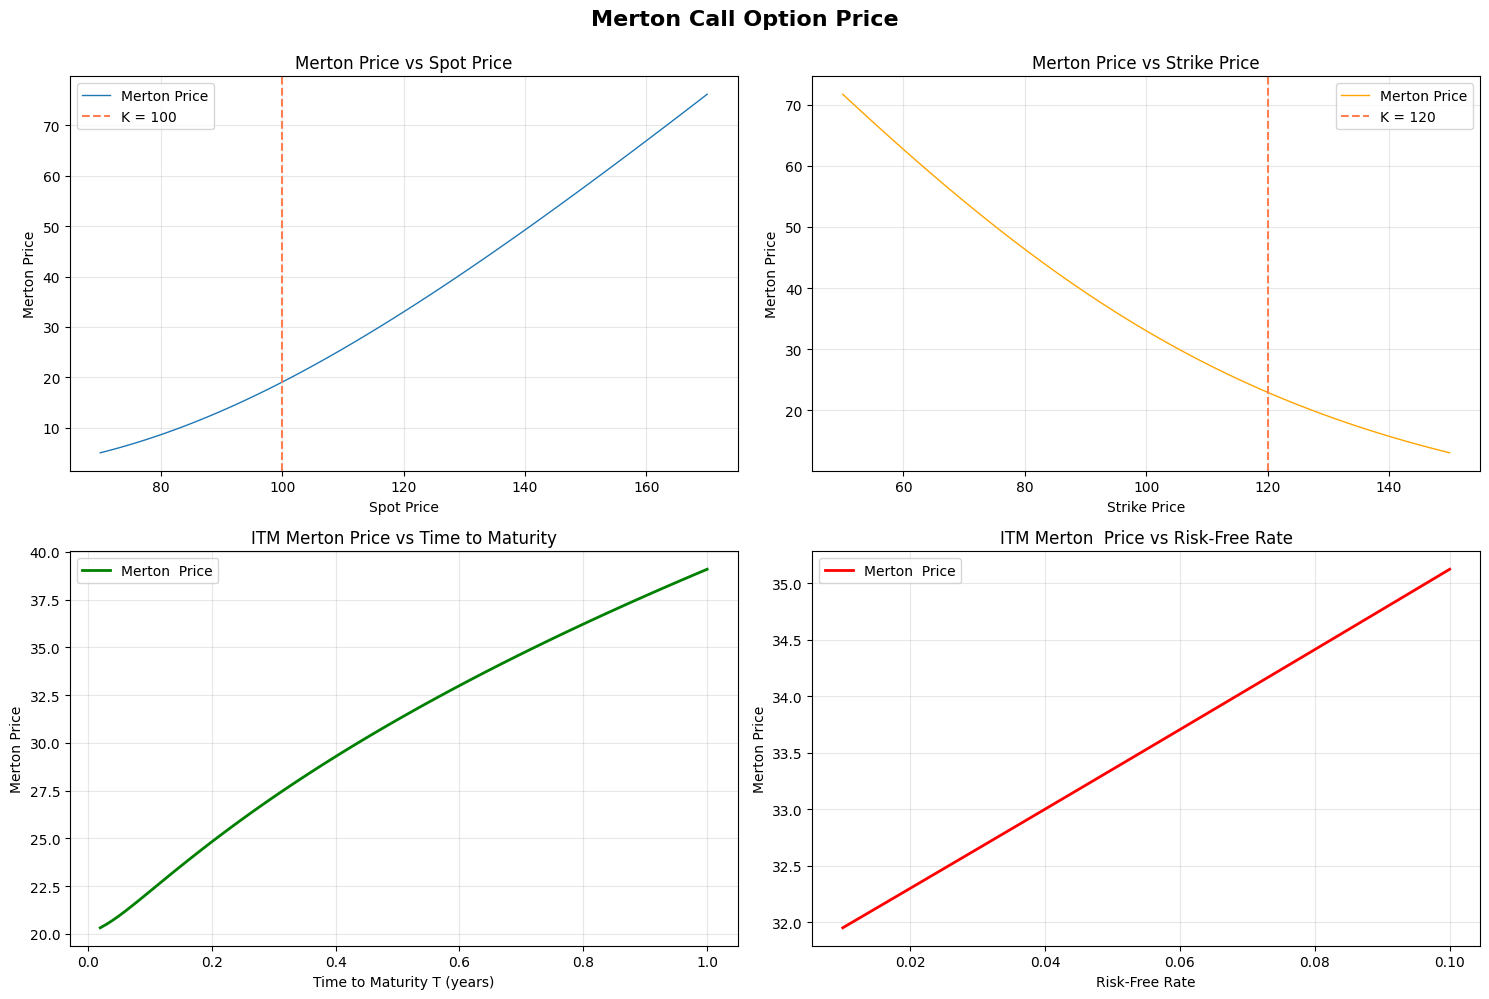

In [66]:
# ITM (In-The-Money) Calls: K < S0

S0_base, K_base, T_base, r_base, = 120, 100, 0.6, 0.04

S0_range = np.linspace(70, 170, 100)
K_range = np.linspace(50, 150, 100)
T_range = np.linspace(0.02, 1, 100)
r_range = np.linspace(0.01, 0.10, 100)

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('Merton Call Option Price', fontsize=16, fontweight='bold', y=0.995)
 
# 1. Varying S0 (Spot Price)
ax = axes[0, 0]
merton_prices_S0 = [CallOptionMerton(S0, K_base, T_base, r_base, sig, lam, muJ, deJ).price() for S0 in S0_range]
ax.plot(S0_range, merton_prices_S0, linewidth=1, label='Merton Price')
ax.axvline(x=K_base, color='coral', linestyle='--', linewidth=1.5, label=f'K = {K_base}')
ax.set_xlabel('Spot Price')
ax.set_ylabel('Merton Price')
ax.set_title('Merton Price vs Spot Price')
ax.legend()
ax.grid(True, alpha=0.3)
 
# 2. Varying K (Strike Price)
ax = axes[0, 1]
merton_prices_K = [CallOptionMerton(S0_base, K, T_base, r_base, sig, lam, muJ, deJ).price() for K in K_range]
ax.plot(K_range, merton_prices_K, linewidth=1, label='Merton Price', color='orange')
ax.axvline(x=S0_base, color='coral', linestyle='--', linewidth=1.5, label=f'K = {S0_base}')
ax.set_xlabel('Strike Price')
ax.set_ylabel('Merton Price')
ax.set_title('Merton Price vs Strike Price')
ax.legend()
ax.grid(True, alpha=0.3)
 
# 3. Varying T (Time to Maturity)
ax = axes[1, 0]
merton_prices_T = [CallOptionMerton(S0_base, K_base, T, r_base, sig, lam, muJ, deJ).price() for T in T_range]
ax.plot(T_range, merton_prices_T, linewidth=2, label='Merton  Price', color='green')
ax.set_xlabel('Time to Maturity T (years)')
ax.set_ylabel('Merton Price')
ax.set_title('ITM Merton Price vs Time to Maturity')
ax.legend()
ax.grid(True, alpha=0.3)
 
# 4. Varying r (Risk-Free Rate)
ax = axes[1, 1]
merton_prices_r = [CallOptionMerton(S0_base, K_base, T_base, r, sig, lam, muJ, deJ).price() for r in r_range]
ax.plot(r_range, merton_prices_r, linewidth=2, label='Merton  Price', color='red')
ax.set_xlabel('Risk-Free Rate')
ax.set_ylabel('Merton Price')
ax.set_title('ITM Merton  Price vs Risk-Free Rate')
ax.legend()
ax.grid(True, alpha=0.3)
 

plt.subplots_adjust(hspace=0.5) 
plt.tight_layout()
plt.show()


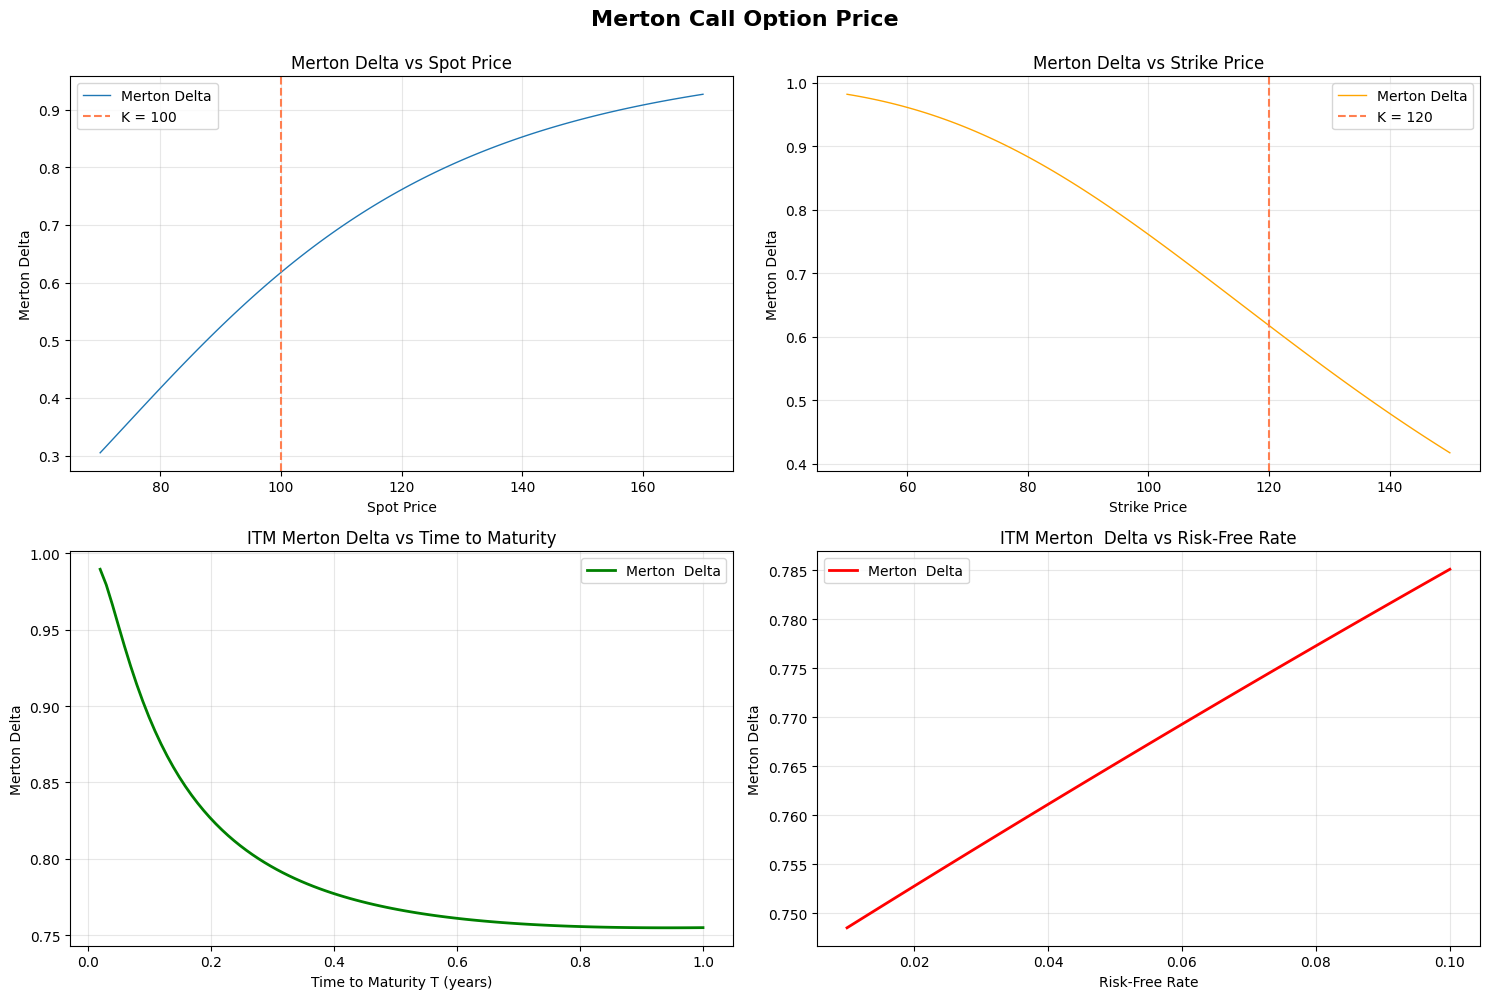

In [67]:
# ITM (In-The-Money) Calls: K < S0

S0_base, K_base, T_base, r_base, = 120, 100, 0.6, 0.04

S0_range = np.linspace(70, 170, 100)
K_range = np.linspace(50, 150, 100)
T_range = np.linspace(0.02, 1, 100)
r_range = np.linspace(0.01, 0.10, 100)

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('Merton Call Option Price', fontsize=16, fontweight='bold', y=0.995)
 
# 1. Varying S0 (Spot Price)
ax = axes[0, 0]
merton_delta_S0 = [CallOptionMerton(S0, K_base, T_base, r_base, sig, lam, muJ, deJ).delta() for S0 in S0_range]
ax.plot(S0_range, merton_delta_S0, linewidth=1, label='Merton Delta')
ax.axvline(x=K_base, color='coral', linestyle='--', linewidth=1.5, label=f'K = {K_base}')
ax.set_xlabel('Spot Price')
ax.set_ylabel('Merton Delta')
ax.set_title('Merton Delta vs Spot Price')
ax.legend()
ax.grid(True, alpha=0.3)
 
# 2. Varying K (Strike Price)
ax = axes[0, 1]
merton_delta_K = [CallOptionMerton(S0_base, K, T_base, r_base, sig, lam, muJ, deJ).delta() for K in K_range]
ax.plot(K_range, merton_delta_K, linewidth=1, label='Merton Delta', color='orange')
ax.axvline(x=S0_base, color='coral', linestyle='--', linewidth=1.5, label=f'K = {S0_base}')
ax.set_xlabel('Strike Price')
ax.set_ylabel('Merton Delta')
ax.set_title('Merton Delta vs Strike Price')
ax.legend()
ax.grid(True, alpha=0.3)
 
# 3. Varying T (Time to Maturity)
ax = axes[1, 0]
merton_delta_T = [CallOptionMerton(S0_base, K_base, T, r_base, sig, lam, muJ, deJ).delta() for T in T_range]
ax.plot(T_range, merton_delta_T, linewidth=2, label='Merton  Delta', color='green')
ax.set_xlabel('Time to Maturity T (years)')
ax.set_ylabel('Merton Delta')
ax.set_title('ITM Merton Delta vs Time to Maturity')
ax.legend()
ax.grid(True, alpha=0.3)
 
# 4. Varying r (Risk-Free Rate)
ax = axes[1, 1]
merton_delta_r = [CallOptionMerton(S0_base, K_base, T_base, r, sig, lam, muJ, deJ).delta() for r in r_range]
ax.plot(r_range, merton_delta_r, linewidth=2, label='Merton  Delta', color='red')
ax.set_xlabel('Risk-Free Rate')
ax.set_ylabel('Merton Delta')
ax.set_title('ITM Merton  Delta vs Risk-Free Rate')
ax.legend()
ax.grid(True, alpha=0.3)
 

plt.subplots_adjust(hspace=0.5) 
plt.tight_layout()
plt.show()


### 5.3 Dynamic Delta Hedging Using Merton Model

In [68]:
def merton_hedging(S, k, n, r, sig, lam, muJ, deltaJ, x=1):
    """
    Calculate dynamic delta hedging payout using Merton's model.
    
    Parameters:
    -----------
    S : array-like
        Array of closing prices (length >= n+1)
    k : float
        Ratio of strike price over initial price: K = k * S[0]
    n : integer
        Trading days to maturity (will be normalized by N=252)
    r : float
        Risk-free interest rate
    sig : float
        Model Volatility
    lam : float
        Jump intensity
    muJ : float
        Jump size expectation
    deltaJ : float
        Jump size variance
    x : hedging ratio relative to Delta. 
        x > 1 means more hedging, x < 1 means less hedging
    
    Returns:
    --------
    payout : float
        Dynamic delta hedging payout
    """
    
    N = 252  # Annual trading days
    
    # Check if we have enough data points
    if len(S) < n + 1:
        return np.nan
    
    # Take the last n+1 data points
    S = np.asarray(S[-n-1:])
    
    # Strike price
    K = k * S[0]
    
    # Day n payout: discounted intrinsic value
    S_n = S[-1]
    payout = np.exp(-r * n / N) * max(S_n - K, 0)
    
    # Hedging cost: sum of (stock price change - hedging profit) * discount factor
    hedging_cost = 0.0
    
    for i in range(n):
        S_i = S[i]
        S_i_plus_1 = S[i + 1]
        
        # Time to maturity at step i
        T_i = (n - i) / N
        
        # Delta at step i
        delta_i = CallOptionMerton(S_i, K, T_i, r, sig, lam, muJ, deltaJ).delta()
        
        # Stock price change
        stock_change = S_i_plus_1 - np.exp(r / N) * S_i
        
        # Discount factor for step i+1
        discount = np.exp(-r * (i + 1) / N)
        
        # Hedging cost contribution
        hedging_cost += stock_change * x * delta_i * discount
    
    # Total payout
    total_payout = payout - hedging_cost
    
    return total_payout

In [69]:
sig, lam, muJ, deJ 

(0.452976, 1.647672, -0.087469, 0.31279)

In [77]:
# ATM Options
k = 1.0  
n = 40    
N = 252   
r = 0.05  
T = n / N 
 
S_values = tsla_history["Close"].values

# Calculate metrics for each point
merton_payouts = []
more_hedging_payouts = []
less_hedging_payouts = []
discounted_payouts = []
merton_prices = []
dates = []
close_prices = []  # Store prices at each iteration
 
# Start from day n onwards
for i in range(n, len(S_values)):  # Use len(S_values) consistently
    S_0 = S_values[i - n]  
    S_n = S_values[i]      
    K = k * S_0
    
    # Dynamic delta hedging payout
    payout = merton_hedging(S_values[:i+1], k, n, r, sig2, lam2, muJ2, deJ2, x=1)    
    merton_payouts.append(payout)
    
    # Actual option payout
    discounted_payout = np.exp(-r*T) * max(S_n - K, 0)
    discounted_payouts.append(discounted_payout)
    
    # Call option price
    merton_price = CallOptionMerton(S_0, K, r, sig, T, lam, muJ, deJ).price()
    merton_prices.append(merton_price)
    
    # Store close price and date
    close_prices.append(S_n)
    dates.append(tsla_history["Close"].index[i].date())

# Create dataframe with matched lengths
tsla_ddh_merton = pd.DataFrame({
    'Close': close_prices,
    'Discounted_Payout': discounted_payouts,
    'Merton_Price': merton_prices,
    'MertonH_Payout': merton_payouts
}, index=dates)

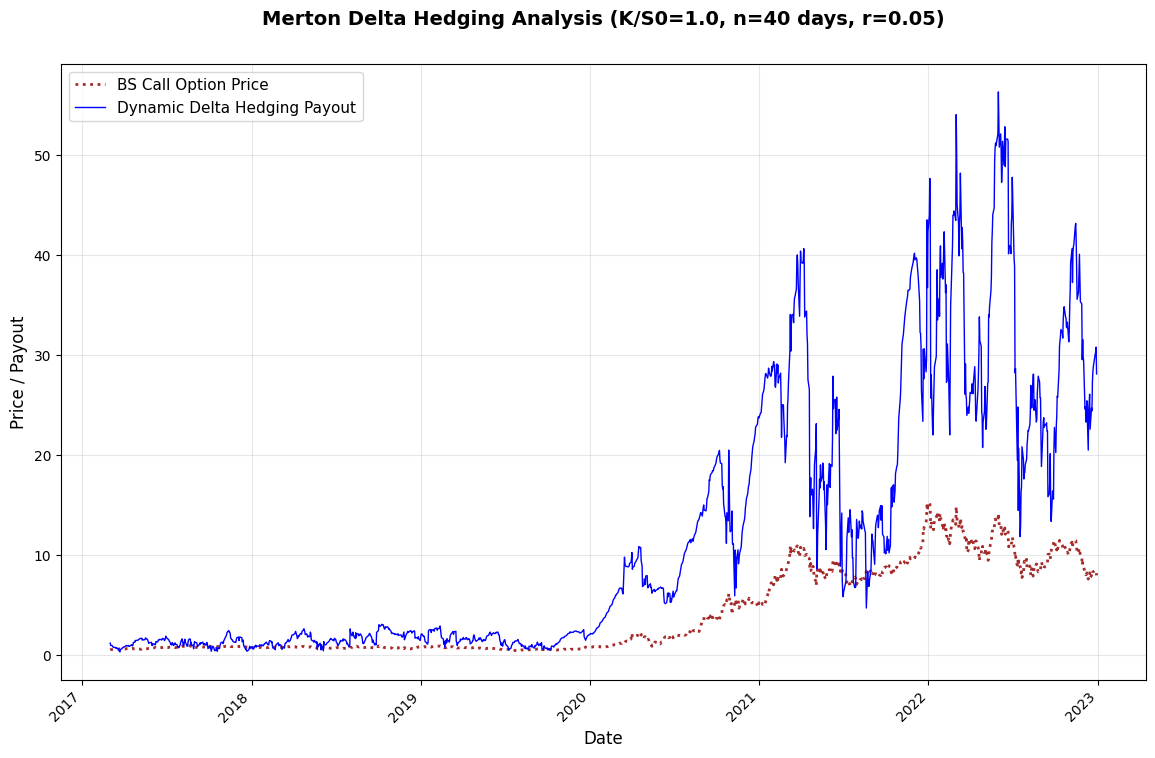

In [78]:
# Plot
fig, ax = plt.subplots(figsize=(14, 8))
 
# Plot three curves 
ax.plot(tsla_ddh_merton.index, tsla_ddh_merton['Merton_Price'], 
        linewidth=2, label='BS Call Option Price', color='brown', linestyle=':')

ax.plot(tsla_ddh_merton.index, tsla_ddh_merton['MertonH_Payout'], 
        linewidth=1, label='Dynamic Delta Hedging Payout', color='blue')

#ax.plot(tsla_ddh_merton.index, tsla_ddh_merton['MD_Payout'], 
#        linewidth=1, label='More Hedging', color='blue', linestyle=':')

#ax.plot(tsla_ddh_merton.index, tsla_ddh_merton['LD_Payout'], 
#        linewidth=1, label='Less Hedging', color='blue', linestyle='--')
 
# Labels and formatting
ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Price / Payout', fontsize=12)
ax.set_title(f'Merton Delta Hedging Analysis (K/S0={k}, n={n} days, r={r})', 
             fontsize=14, fontweight='bold', y=1.05)
ax.legend(fontsize=11, loc='best')
ax.grid(True, alpha=0.3)
 
plt.xticks(rotation=45, ha='right')
 
plt.show()
 

In [72]:
#For comparison, reproduce the data for Black-Scholes Dynamic Delta Hedging
# ATM Options with 2-month expiration 
# standard Delta Hedging: x = 1 
k = 1.0  # Ratio of Strike price over S0
n = 40    # Trading days
N = 252   # Annual trading days
r = 0.05  # Risk-free rate
T = n / N # Time to maturity in years
 
# Extract arrays
S_values = tsla_close_hv['Close_Price'].values
hv_values = tsla_close_hv['Historical_Volatility'].values
 
# Calculate metrics for each point
ddh_payouts = []
discounted_payouts = []
call_prices = []
dates = []
 
# Start from day n onwards
for i in range(n, len(tsla_close_hv)):
    S_0 = S_values[i - n]  # Initial price (n days ago)
    S_n = S_values[i]      # Final price (today)
    K = k * S_0
    hv_i = hv_values[i]
    
    # Dynamic delta hedging payout
    payout = dynamic_delta_hedging(S_values[:i+1], hv_values[:i+1], k, n, r, x=1)
    ddh_payouts.append(payout)
    
    # Actual option payout discounted to day 0: e^(-rT)max(S_n - K, 0)
    discounted_payout = np.exp(-r*T) * max(S_n - K, 0)
    discounted_payouts.append(discounted_payout)
    
    # Call option price at inception: c(S_0, K, T, r, hv)
    call_price = CallOptionBS(S_0, K, T, r, hv_i).price()
    call_prices.append(call_price)
    
    dates.append(tsla_close_hv.index[i].date())
 
# Create dataframe with all metrics
tsla_ddh_analysis = pd.DataFrame({
    'Close': S_values[n:len(S_values)],
    'Discounted_Payout': discounted_payouts,
    'Call_Price': call_prices,
    'DDH_Payout': ddh_payouts
}, index=dates)
 

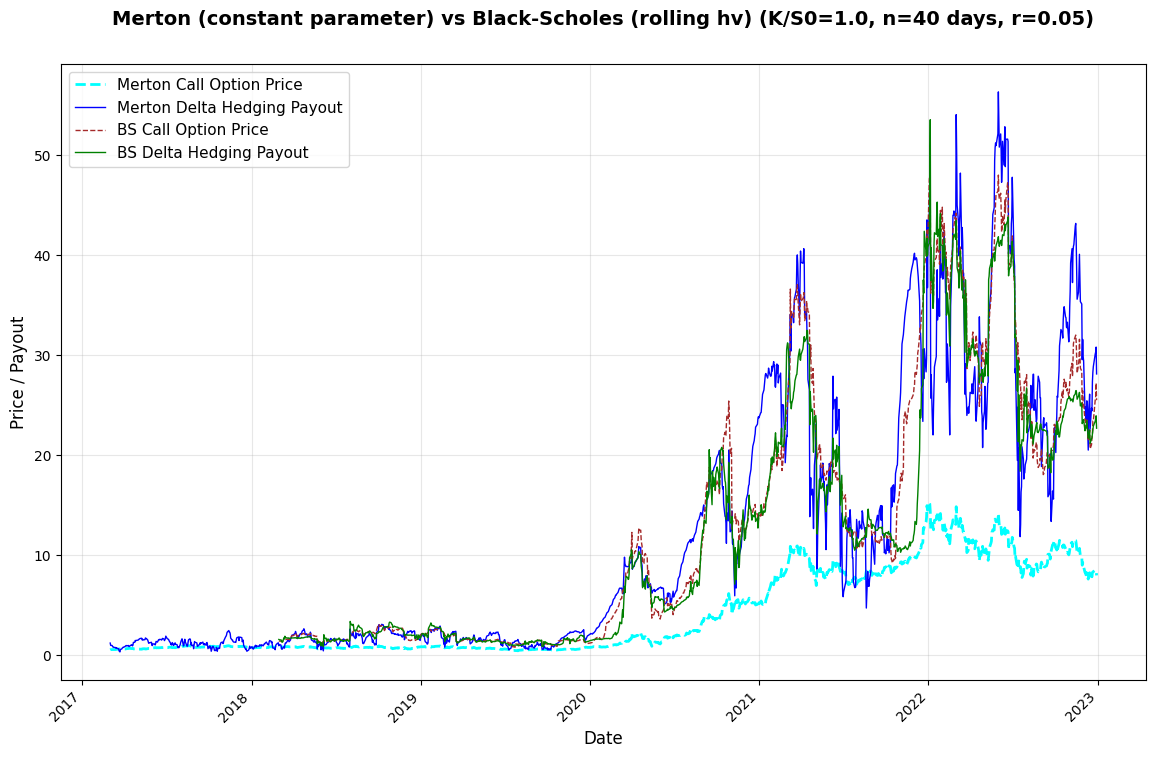

In [79]:
# Plot
fig, ax = plt.subplots(figsize=(14, 8))
 
# Plot three curves 
ax.plot(tsla_ddh_merton.index, tsla_ddh_merton['Merton_Price'], 
        linewidth=2, label='Merton Call Option Price', color='cyan', linestyle='--')

ax.plot(tsla_ddh_merton.index, tsla_ddh_merton['MertonH_Payout'], 
        linewidth=1, label='Merton Delta Hedging Payout', color='blue')

ax.plot(tsla_ddh_analysis.index, tsla_ddh_analysis['Call_Price'], 
        linewidth=1, label='BS Call Option Price', color='brown', linestyle='--')

ax.plot(tsla_ddh_analysis.index, tsla_ddh_analysis['DDH_Payout'], 
        linewidth=1, label='BS Delta Hedging Payout', color='green')
 
# Labels and formatting
ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Price / Payout', fontsize=12)
ax.set_title(f'Merton (constant parameter) vs Black-Scholes (rolling hv) (K/S0={k}, n={n} days, r={r})', 
             fontsize=14, fontweight='bold', y=1.05)
ax.legend(fontsize=11, loc='best')
ax.grid(True, alpha=0.3)
 
plt.xticks(rotation=45, ha='right')
 
plt.show()
 

## 6. Summary: Merton vs Black-Scholes Delta Hedging

1. **Model Equivalence**: Merton dynamic delta hedging payouts closely track Black-Scholes payouts using 2-month rolling historical volatility, suggesting calibrated jump parameters effectively capture recent price dynamics.

2. **Pricing Consistency**: Both hedging payout curves align with Black-Scholes call prices (with historical volatility), confirming that realized P&L from hedging approximates theoretical option premiums.

3. **Merton Undervaluation**: All three measures trade above Merton prices with fixed parameters, indicating the static calibration undervalues options relative to market conditions.

4. **IV-HV Alignment**: Implied volatility (from BS inversion) matches rolling historical volatility, validating that market prices and realized dynamics are consistent.